# Code to make heatmaps using latent representations of data in LLMs!

In [1]:
## == CUSTOM HELPER FUNCTIONS == ##
import torch
import gc
import analysis_functions as topo
import heatmap_functions as ling
import contour_overlay as cont

/Users/kimlopez/TDA_RI/TDA_reason-interpret/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
## == DATASETS == ##
# [0]: hellaswag, [1]-[5]: mmlu
datasets = [["hellaswag", "~/TDA_RI/TDA_reason-interpret/datasets/hellaswag.csv"],
            ["mmlu_law", "~/TDA_RI/TDA_reason-interpret/datasets/mmlu_law.csv"],
            ["mmlu_math", "~/TDA_RI/TDA_reason-interpret/datasets/mmlu_math.csv"],
            ["mmlu_misc", "~/TDA_RI/TDA_reason-interpret/datasets/mmlu_misc.csv"],
            ["mmlu_moral", "~/TDA_RI/TDA_reason-interpret/datasets/mmlu_moral.csv"],
            ["mmlu_psych", "~/TDA_RI/TDA_reason-interpret/datasets/mmlu_psych.csv"],
            ["mcqa", "~/TDA_RI/TDA_reason-interpret/datasets/mcqa.csv"]]

## == MODELS == ##
# [0]: Llama, [1]: Qwen, [2]: Mistral
models = [["Llama 3.1 8B", "meta-llama/Llama-3.1-8B", "llama"],
          ["Qwen 3 8B", "Qwen/Qwen3-8B", "qwen"],
          ["Mistral 7B v0.3", "mistralai/Mistral-7B-v0.3", "mistral"]]

Sampling 100 correct and 100 incorrect examples
+--------------------+-----------------------+------------------------+------------------------+-------------------------+-----------------------+-----------------------+
|       label        |        num_feat       |        max_feat        | max_feat_minus_second  |        mean_feat        |      betti_curve      |  persistence_entropy  |
+--------------------+-----------------------+------------------------+------------------------+-------------------------+-----------------------+-----------------------+
|    correct_0dim    |         86.39         |   0.8870138549804687   |  0.00857940673828125   |    0.7475771329115685   |   72.26880000000001   |   4.377428250499401   |
| correct_0dim_stdv  |   3.767803395115306   | 0.0017569200932201095  | 0.0007758957307616121  |  0.0019354781914104773  |   3.193016791042413   |   0.037993110634607   |
|    correct_1dim    |          0.04         |  0.000494232177734375  |  0.000494232177734375  | 

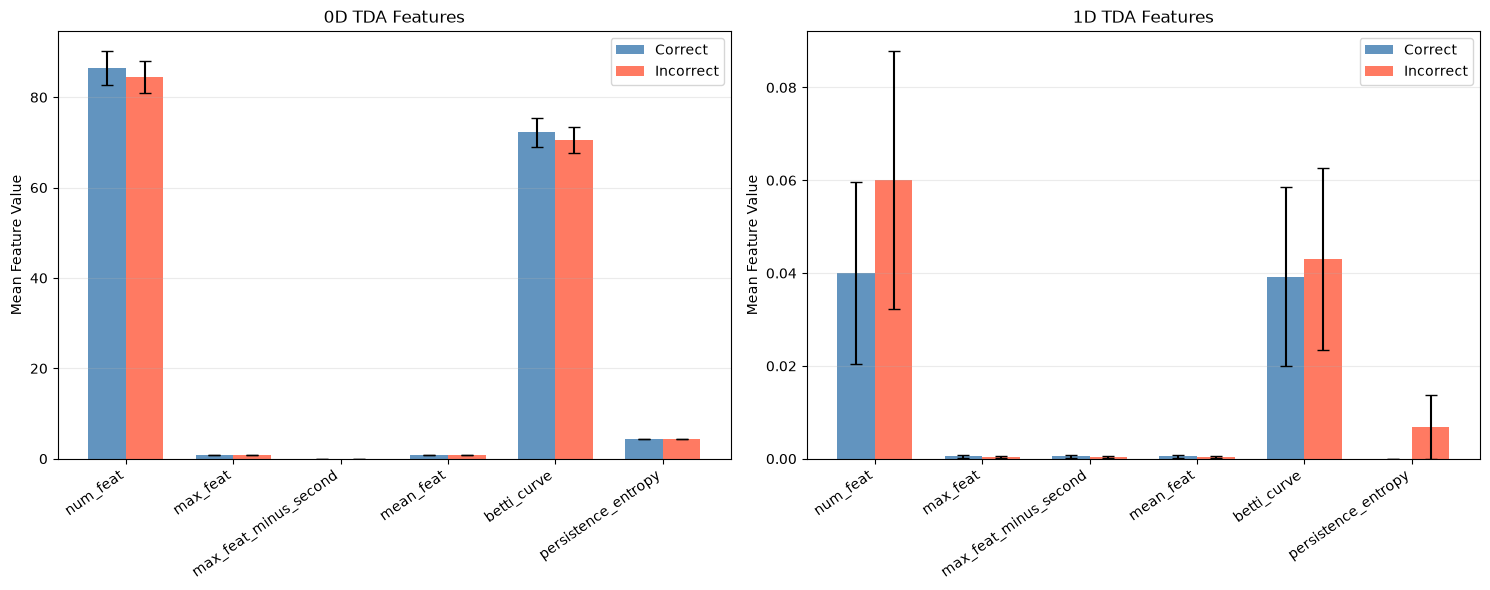

0

In [3]:
# prelim analysis
topo.analyze_feats(models[2], datasets[5], False)

In [4]:
# heatmap labels
linguistic_labels = [['Linguistic Features',["num_tokens", "num_types", "avg_word_length", "char_count",
                        "ttr", "cttr", "herdan_c", "simpson_div", "yules_k",
                        "num_content_words", "lexical_density",
                        "avg_polysemy", "num_long_words", "long_word_ratio", "hapax_legomena", "hapax_ratio",
                        "num_stopwords", "stopword_ratio",
                        "noun_ratio", "verb_ratio", "adj_ratio", "adv_ratio",
                        "entropy", "top_word_freq",
                        "unique_bigram_approx"]]
]

tda_labels = [["Topological Features", ['Num_0dim', 'Max_0dim', 'Max_0dim_Minus_Second', 'Mean_0dim', 'betti_curve_0', 'persistence_entropy_0', 'Num_1dim', 'Max_1dim', 'Max_1dim_Minus_Second', 'Mean_1dim', 'betti_curve_1', 'persistence_entropy_1']],
              ["h0 Features", ["Num_0dim", "Max_0dim", "Mean_0dim", "betti_curve_0", "persistence_entropy_0"]],
              ["h1 Features", ["Num_1dim", "Max_1dim", "Mean_1dim", "betti_curve_1", "persistence_entropy_1"]]
]

print("# features: ", len(linguistic_labels[0][1]))

# features:  25


Sampling 100 correct and 100 incorrect examples
Correct samples 0 dim: 100
Incorrect samples 0 dim: 100
Correct samples 1 dim: 0
Incorrect samples 1 dim: 0
Filtration range 0 dim: 0.56835938 0.87652588
Filtration range 1 dim: None None


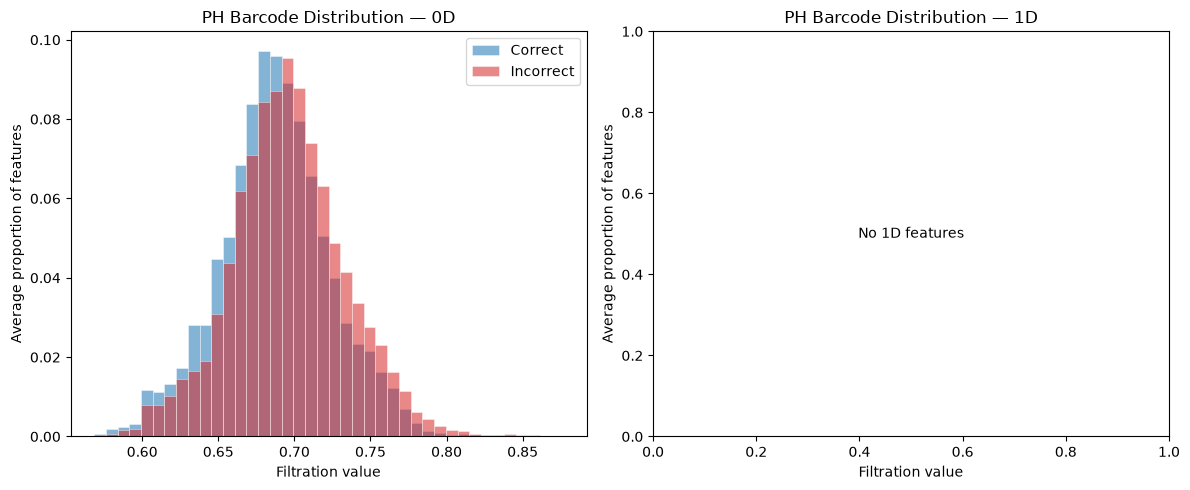

0

In [5]:
topo.plot_barcode(models[0], datasets[0])

model:  ['Llama 3.1 8B', 'meta-llama/Llama-3.1-8B', 'llama']
dataset:  ['hellaswag', '~/TDA_RI/TDA_reason-interpret/datasets/hellaswag.csv']
Sampling 100 correct and 100 incorrect examples
+--------------------+--------------------+-----------------------+------------------------+-----------------------+--------------------+----------------------+
|       label        |      num_feat      |        max_feat       | max_feat_minus_second  |       mean_feat       |    betti_curve     | persistence_entropy  |
+--------------------+--------------------+-----------------------+------------------------+-----------------------+--------------------+----------------------+
|    correct_0dim    |       155.47       |   0.7894708251953125  |   0.0149969482421875   |   0.6874217757181639  | 133.27799999999996 |  4.9193159193438545  |
| correct_0dim_stdv  | 7.317330404076628  |  0.003068095999282179 | 0.0014892902285463254  | 0.0010022960821548734 | 6.086740100456487  | 0.052086012948188355 |
|    c

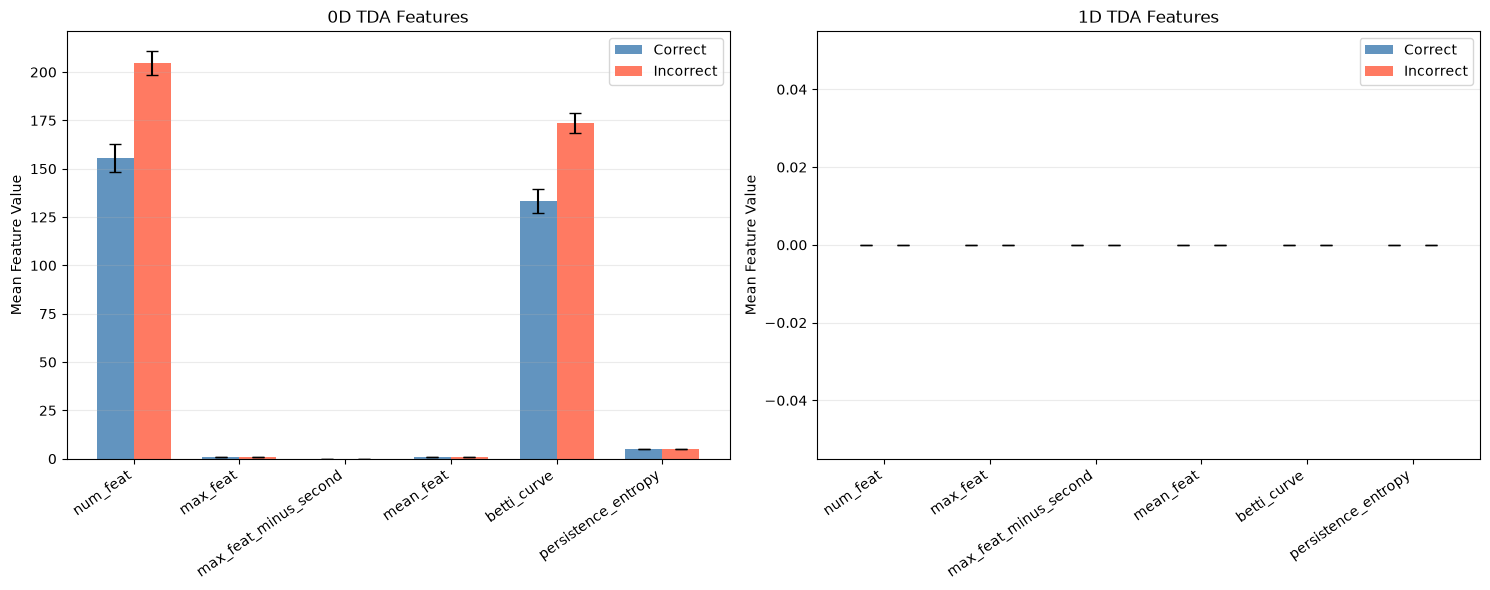

Sampling 100 correct and 100 incorrect examples
Correct samples 0 dim: 100
Incorrect samples 0 dim: 100
Correct samples 1 dim: 0
Incorrect samples 1 dim: 0
Filtration range 0 dim: 0.56835938 0.87652588
Filtration range 1 dim: None None


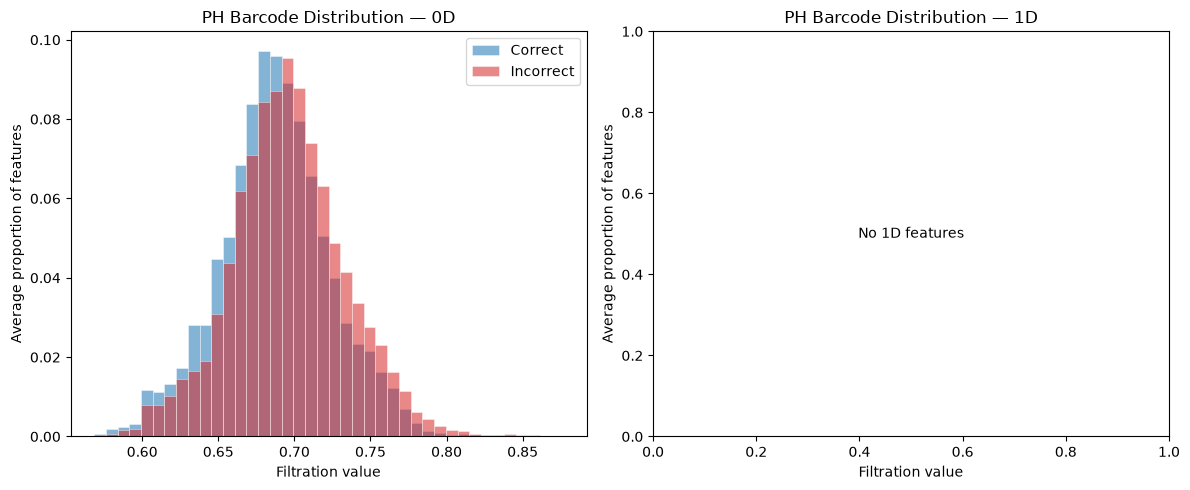

model:  ['Llama 3.1 8B', 'meta-llama/Llama-3.1-8B', 'llama']
dataset:  ['mmlu_law', '~/TDA_RI/TDA_reason-interpret/datasets/mmlu_law.csv']
Sampling 100 correct and 100 incorrect examples
+--------------------+--------------------+------------------------+-----------------------+------------------------+--------------------+-----------------------+
|       label        |      num_feat      |        max_feat        | max_feat_minus_second |       mean_feat        |    betti_curve     |  persistence_entropy  |
+--------------------+--------------------+------------------------+-----------------------+------------------------+--------------------+-----------------------+
|    correct_0dim    |       245.28       |   0.793416748046875    |   0.019019775390625   |   0.6808986887184197   | 208.67219999999998 |   5.436411907932812   |
| correct_0dim_stdv  | 8.284219878171934  | 0.0028779331203894623  | 0.0018311867776101144 | 0.0009275253583834641  | 6.989216935054493  |  0.038426948996005864 

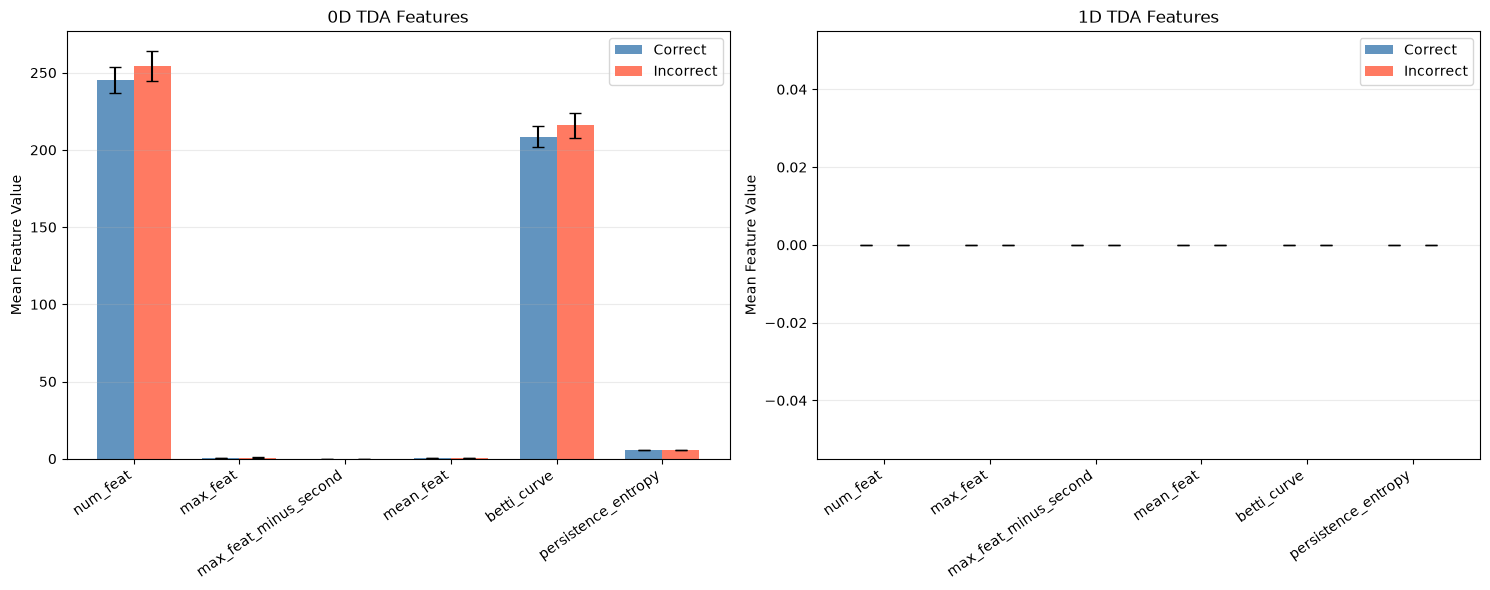

Sampling 100 correct and 100 incorrect examples
Correct samples 0 dim: 100
Incorrect samples 0 dim: 100
Correct samples 1 dim: 0
Incorrect samples 1 dim: 0
Filtration range 0 dim: 0.56835938 0.87365723
Filtration range 1 dim: None None


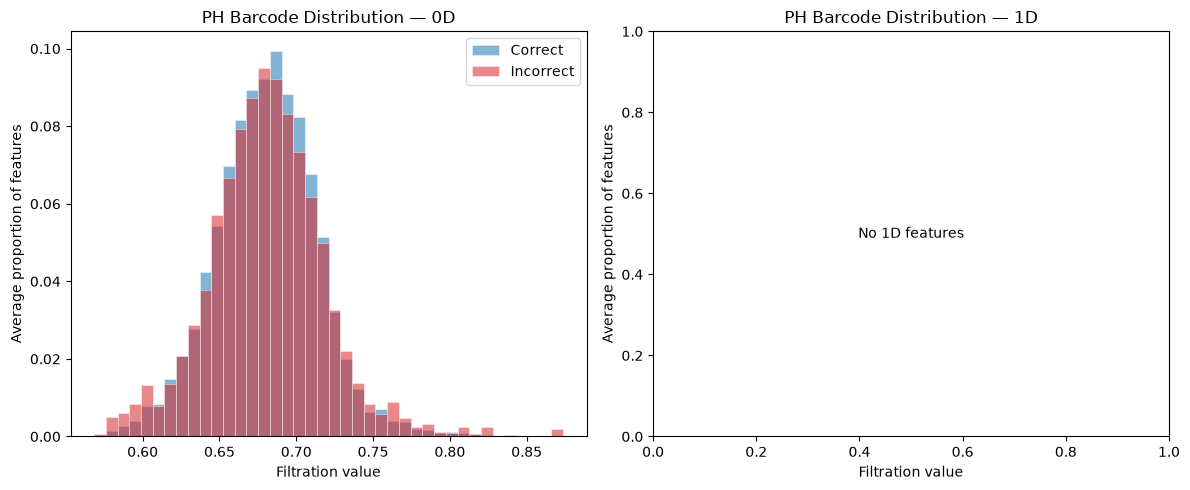

model:  ['Llama 3.1 8B', 'meta-llama/Llama-3.1-8B', 'llama']
dataset:  ['mmlu_math', '~/TDA_RI/TDA_reason-interpret/datasets/mmlu_math.csv']
Sampling 100 correct and 100 incorrect examples
+--------------------+--------------------+------------------------+------------------------+------------------------+---------------------+----------------------+
|       label        |      num_feat      |        max_feat        | max_feat_minus_second  |       mean_feat        |     betti_curve     | persistence_entropy  |
+--------------------+--------------------+------------------------+------------------------+------------------------+---------------------+----------------------+
|    correct_0dim    |       59.85        |   0.765982666015625    |    0.0098876953125     |   0.6889725576430906   |  53.16439999999999  |  4.033586399528727   |
| correct_0dim_stdv  | 2.142422635120052  |  0.001941083727122989  | 0.0009125987263297747  | 0.0012263860474279332  |  1.8223286818371887 | 0.033293952664

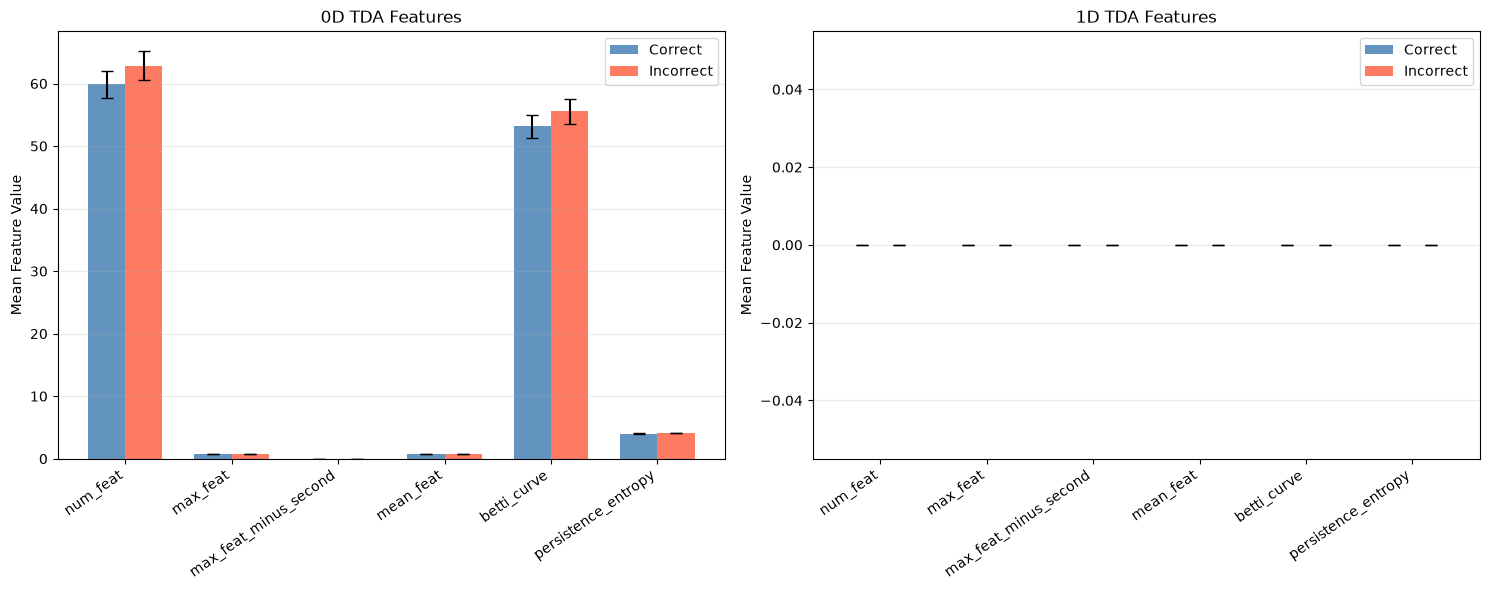

Sampling 100 correct and 100 incorrect examples
Correct samples 0 dim: 100
Incorrect samples 0 dim: 100
Correct samples 1 dim: 0
Incorrect samples 1 dim: 0
Filtration range 0 dim: 0.55371094 0.87316895
Filtration range 1 dim: None None


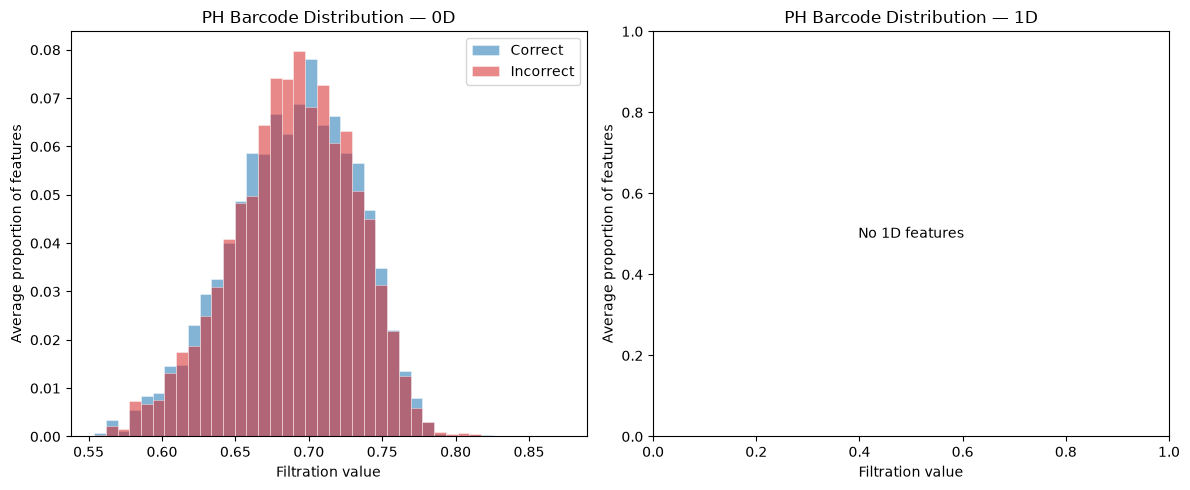

model:  ['Llama 3.1 8B', 'meta-llama/Llama-3.1-8B', 'llama']
dataset:  ['mmlu_misc', '~/TDA_RI/TDA_reason-interpret/datasets/mmlu_misc.csv']
Sampling 100 correct and 100 incorrect examples
+--------------------+--------------------+------------------------+-----------------------+-----------------------+--------------------+----------------------+
|       label        |      num_feat      |        max_feat        | max_feat_minus_second |       mean_feat       |    betti_curve     | persistence_entropy  |
+--------------------+--------------------+------------------------+-----------------------+-----------------------+--------------------+----------------------+
|    correct_0dim    |        45.5        |    0.7602783203125     |     0.009599609375    |   0.6663997736349111  |      39.4266       |  3.727531804934522   |
| correct_0dim_stdv  | 2.4973319095920483 | 0.0016303936722494798  | 0.0009138703241799478 | 0.0007475568486920815 | 2.1131396155359625 | 0.037707303333669735 |
|    c

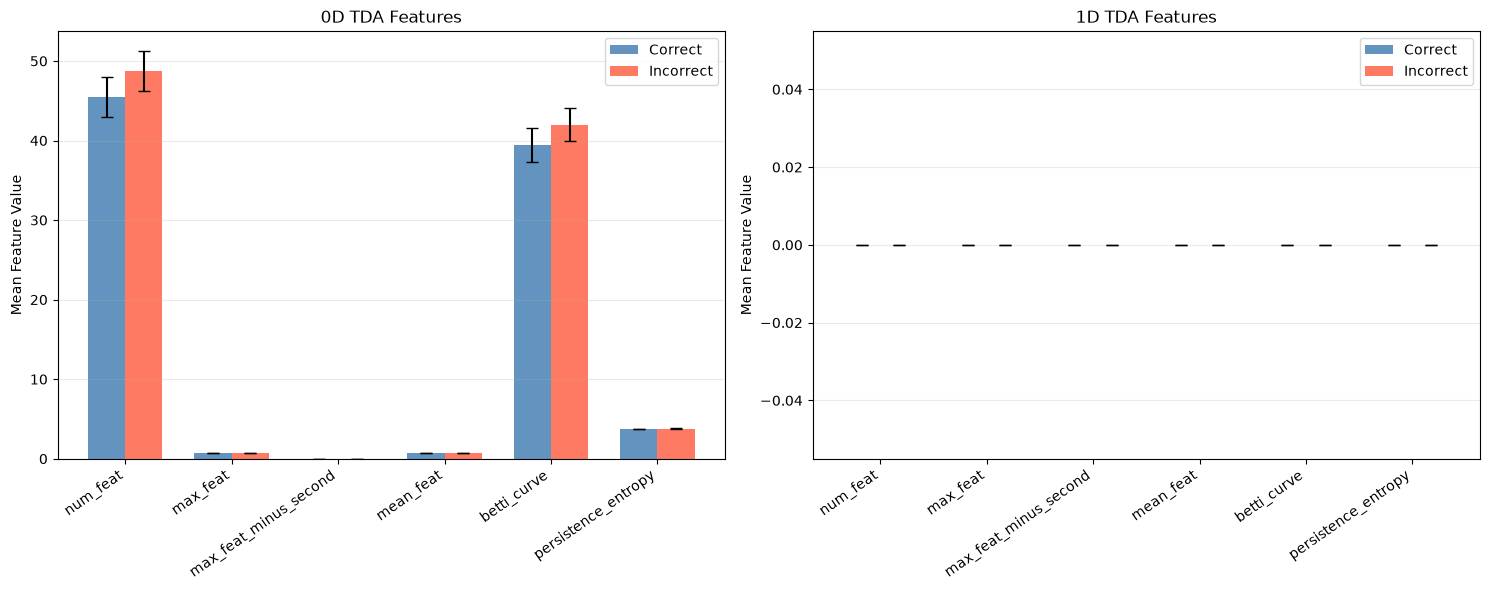

Sampling 100 correct and 100 incorrect examples
Correct samples 0 dim: 100
Incorrect samples 0 dim: 100
Correct samples 1 dim: 0
Incorrect samples 1 dim: 0
Filtration range 0 dim: 0.56176758 0.84924316
Filtration range 1 dim: None None


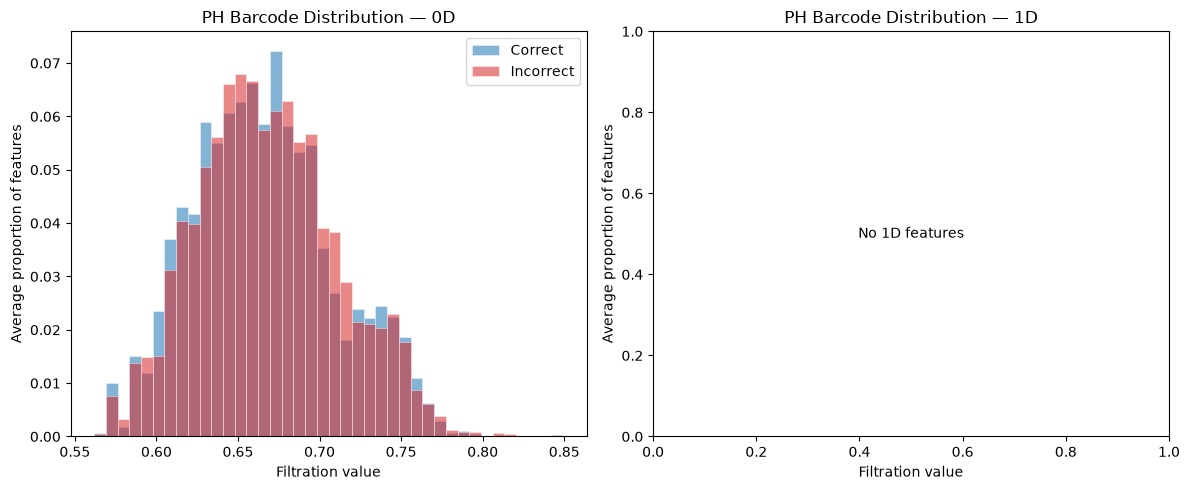

model:  ['Llama 3.1 8B', 'meta-llama/Llama-3.1-8B', 'llama']
dataset:  ['mmlu_moral', '~/TDA_RI/TDA_reason-interpret/datasets/mmlu_moral.csv']
Sampling 100 correct and 100 incorrect examples
+--------------------+--------------------+------------------------+------------------------+------------------------+--------------------+-----------------------+
|       label        |      num_feat      |        max_feat        | max_feat_minus_second  |       mean_feat        |    betti_curve     |  persistence_entropy  |
+--------------------+--------------------+------------------------+------------------------+------------------------+--------------------+-----------------------+
|    correct_0dim    |       103.23       |   0.791185302734375    |    0.01127197265625    |   0.6731983906527502   | 87.11479999999997  |   4.632915534108685   |
| correct_0dim_stdv  | 0.6576442500288128 |  0.001265638731456115  | 0.0010233397127159176  | 0.00016063463749127347 | 0.5587904411957287 | 0.00626535788

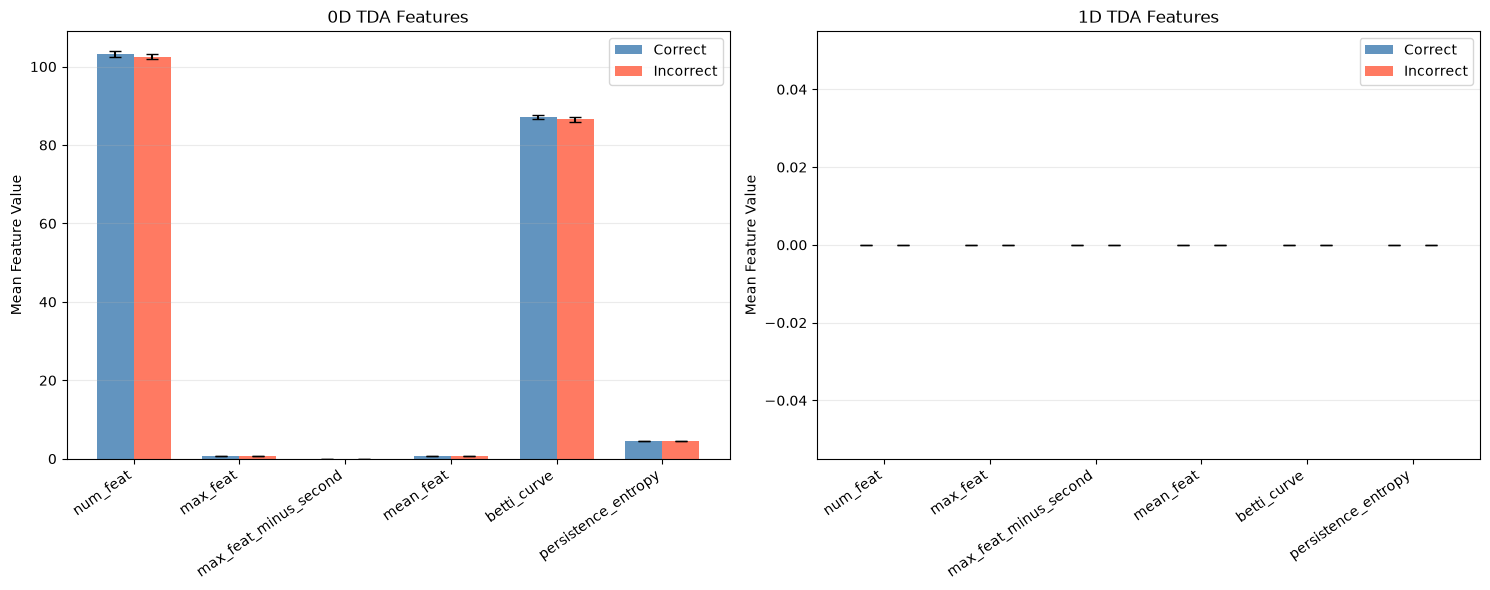

Sampling 100 correct and 100 incorrect examples
Correct samples 0 dim: 100
Incorrect samples 0 dim: 100
Correct samples 1 dim: 0
Incorrect samples 1 dim: 0
Filtration range 0 dim: 0.58544922 0.83911133
Filtration range 1 dim: None None


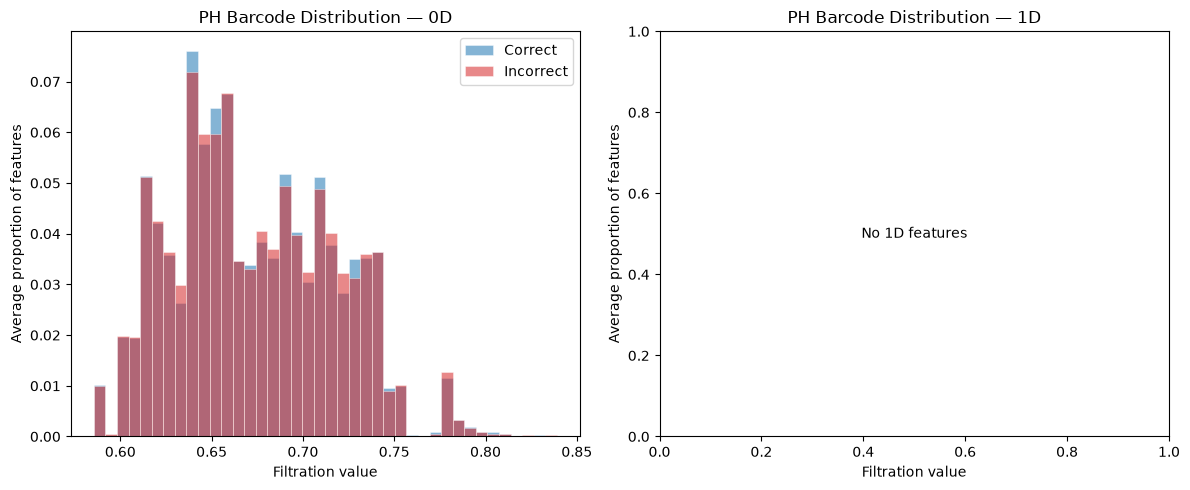

model:  ['Llama 3.1 8B', 'meta-llama/Llama-3.1-8B', 'llama']
dataset:  ['mmlu_psych', '~/TDA_RI/TDA_reason-interpret/datasets/mmlu_psych.csv']
Sampling 100 correct and 100 incorrect examples
+--------------------+---------------------+------------------------+-----------------------+------------------------+---------------------+----------------------+
|       label        |       num_feat      |        max_feat        | max_feat_minus_second |       mean_feat        |     betti_curve     | persistence_entropy  |
+--------------------+---------------------+------------------------+-----------------------+------------------------+---------------------+----------------------+
|    correct_0dim    |        75.78        |   0.768360595703125    |    0.0110400390625    |   0.6697096698707145   |       65.4298       |  4.252208070734995   |
| correct_0dim_stdv  |  3.1789897385137555 | 0.0018066098780492891  | 0.0011302428563223924 | 0.0008346285788553056  |  2.7058639426925435 |  0.037921405

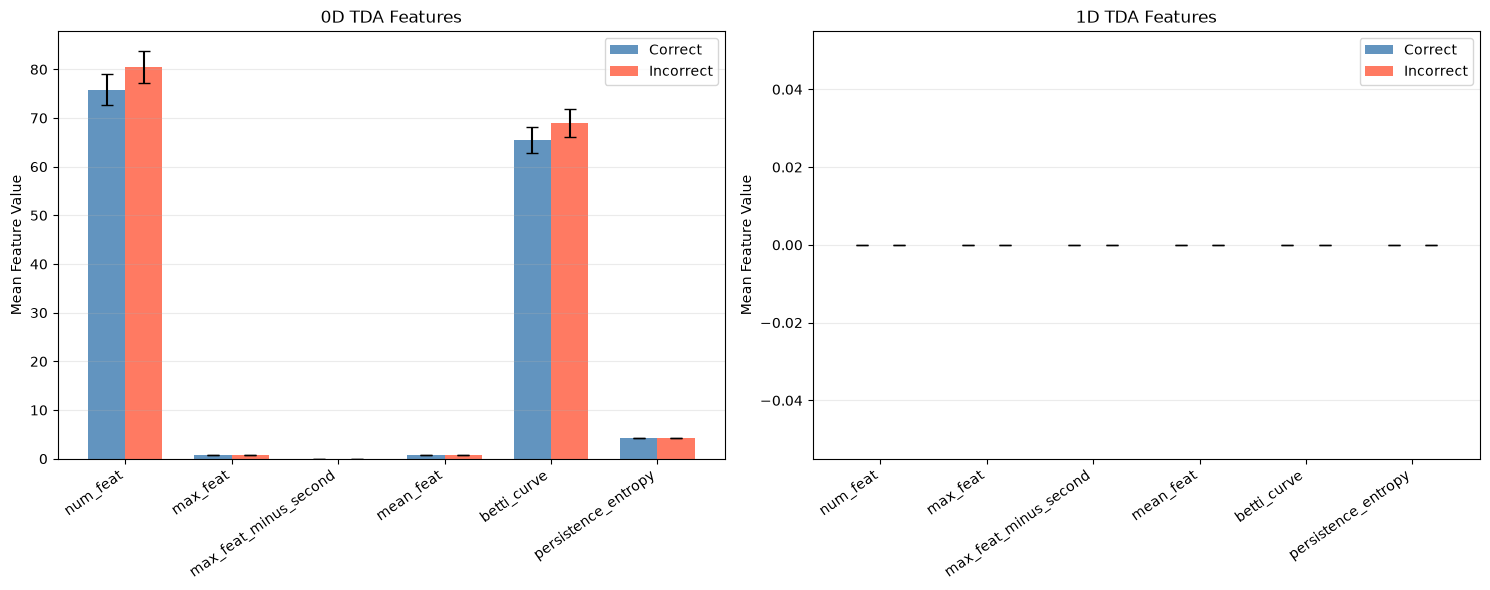

Sampling 100 correct and 100 incorrect examples
Correct samples 0 dim: 100
Incorrect samples 0 dim: 100
Correct samples 1 dim: 0
Incorrect samples 1 dim: 0
Filtration range 0 dim: 0.55249023 0.86230469
Filtration range 1 dim: None None


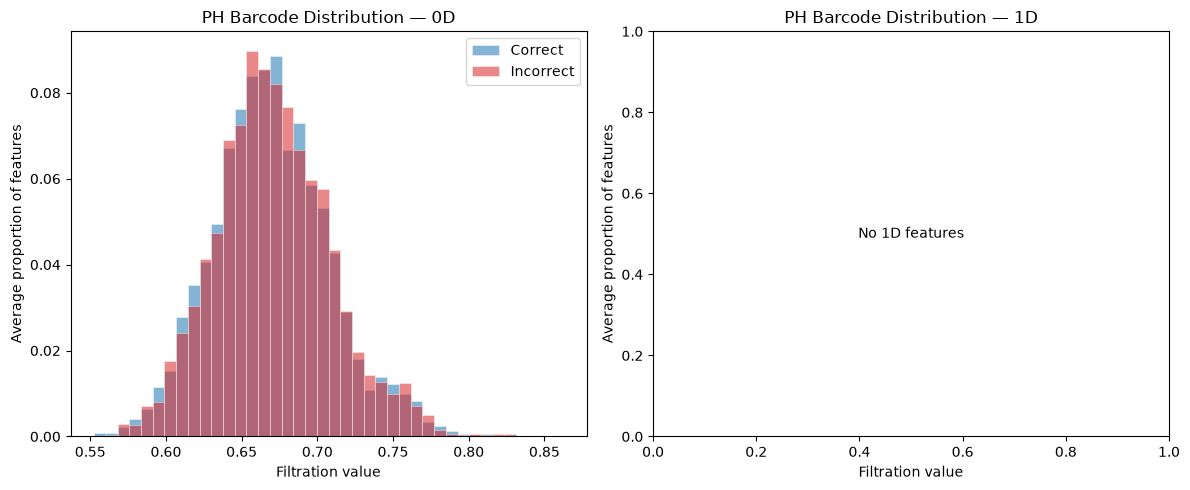

model:  ['Qwen 3 8B', 'Qwen/Qwen3-8B', 'qwen']
dataset:  ['hellaswag', '~/TDA_RI/TDA_reason-interpret/datasets/hellaswag.csv']
Sampling 100 correct and 100 incorrect examples
+--------------------+---------------------+-----------------------+------------------------+------------------------+---------------------+----------------------+
|       label        |       num_feat      |        max_feat       | max_feat_minus_second  |       mean_feat        |     betti_curve     | persistence_entropy  |
+--------------------+---------------------+-----------------------+------------------------+------------------------+---------------------+----------------------+
|    correct_0dim    |        171.42       |   0.8358807373046875  |   0.0177703857421875   |   0.7179922159154546   |       145.054       |  5.016238279795602   |
| correct_0dim_stdv  |  7.550853587442276  | 0.0031941835740123977 | 0.0015849509912932776  | 0.0007917109267551708  |  6.2440893327978255 | 0.054190162875614775 |
|    

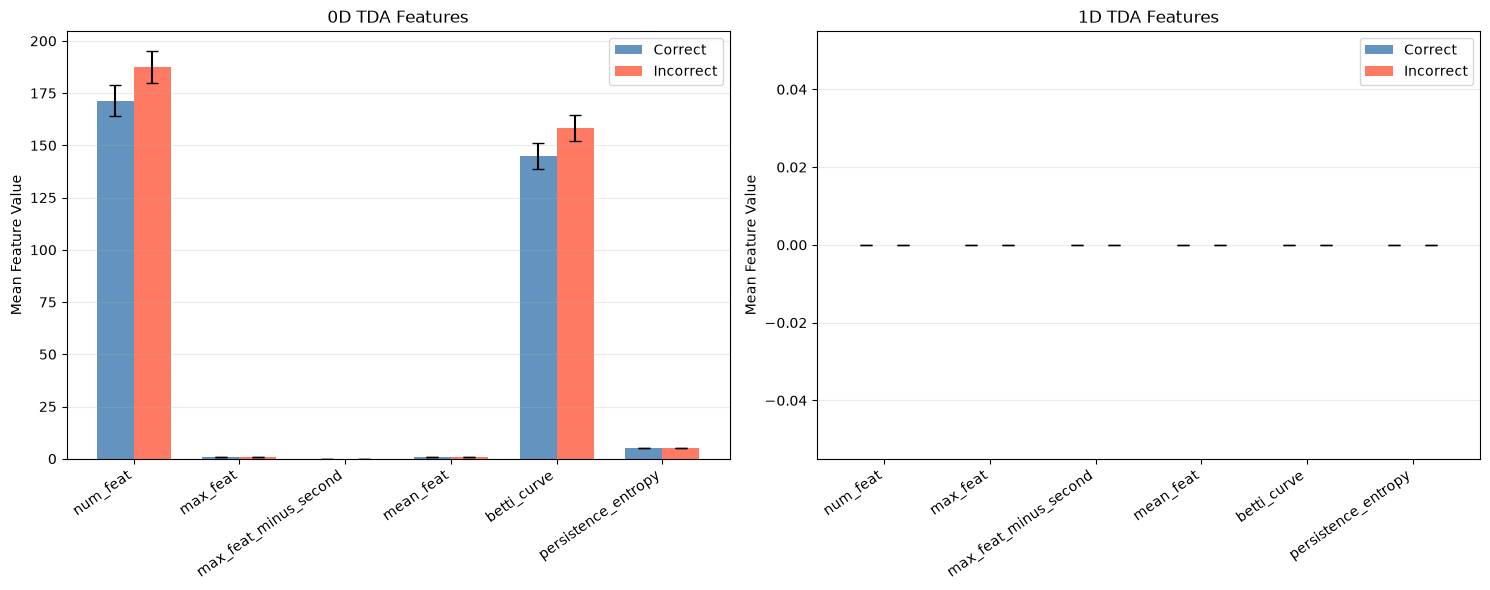

Sampling 100 correct and 100 incorrect examples
Correct samples 0 dim: 100
Incorrect samples 0 dim: 100
Correct samples 1 dim: 0
Incorrect samples 1 dim: 0
Filtration range 0 dim: 0.56958008 0.91094971
Filtration range 1 dim: None None


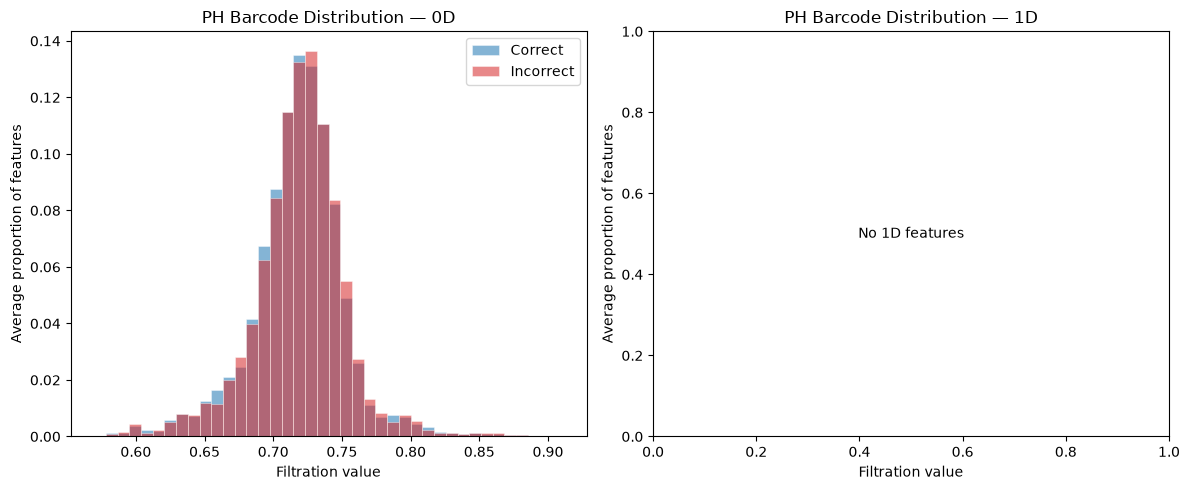

model:  ['Qwen 3 8B', 'Qwen/Qwen3-8B', 'qwen']
dataset:  ['mmlu_law', '~/TDA_RI/TDA_reason-interpret/datasets/mmlu_law.csv']
Sampling 100 correct and 100 incorrect examples
+--------------------+---------------------+-----------------------+-----------------------+------------------------+---------------------+----------------------+
|       label        |       num_feat      |        max_feat       | max_feat_minus_second |       mean_feat        |     betti_curve     | persistence_entropy  |
+--------------------+---------------------+-----------------------+-----------------------+------------------------+---------------------+----------------------+
|    correct_0dim    |        234.57       |   0.839698486328125   |   0.0219158935546875  |   0.7169986097335435   |       198.356       |  5.371227060501952   |
| correct_0dim_stdv  |  8.608948304473138  |  0.003109971159545856 |  0.001865964516939405 | 0.0008608056633907042  |  7.148458425324011  | 0.045984644547780514 |
|    correct

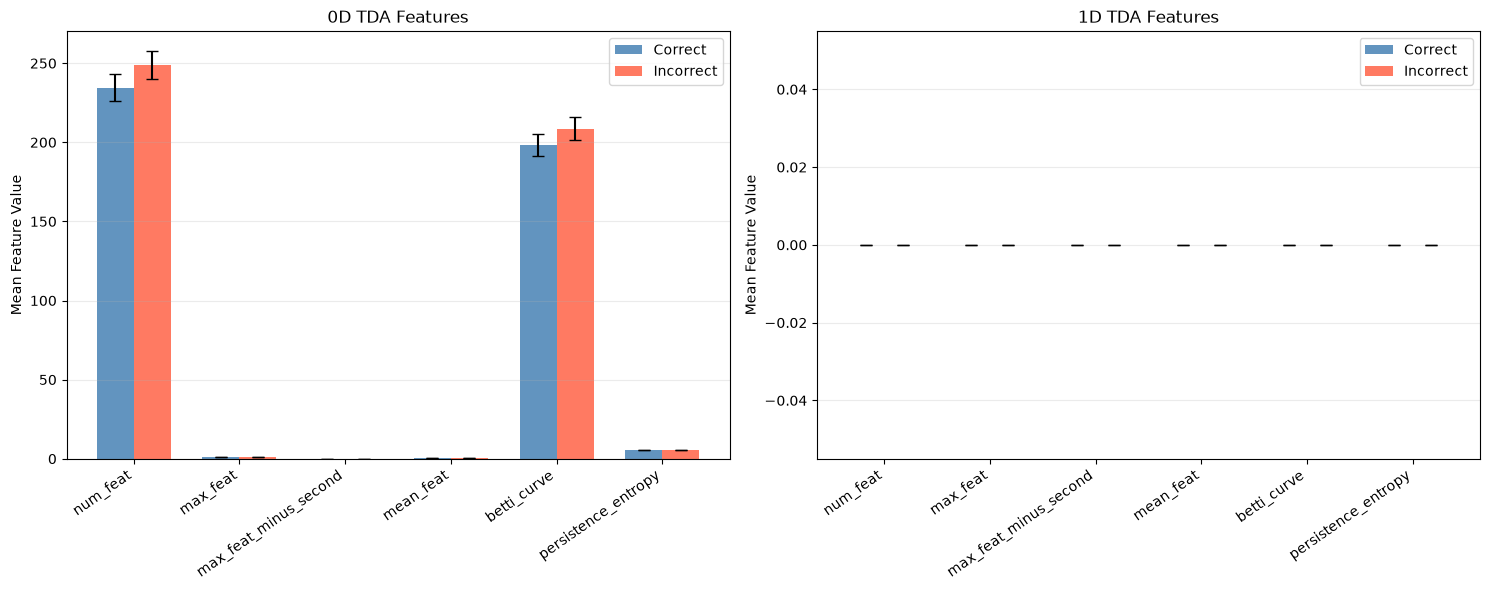

Sampling 100 correct and 100 incorrect examples
Correct samples 0 dim: 100
Incorrect samples 0 dim: 100
Correct samples 1 dim: 0
Incorrect samples 1 dim: 0
Filtration range 0 dim: 0.54858398 0.92059326
Filtration range 1 dim: None None


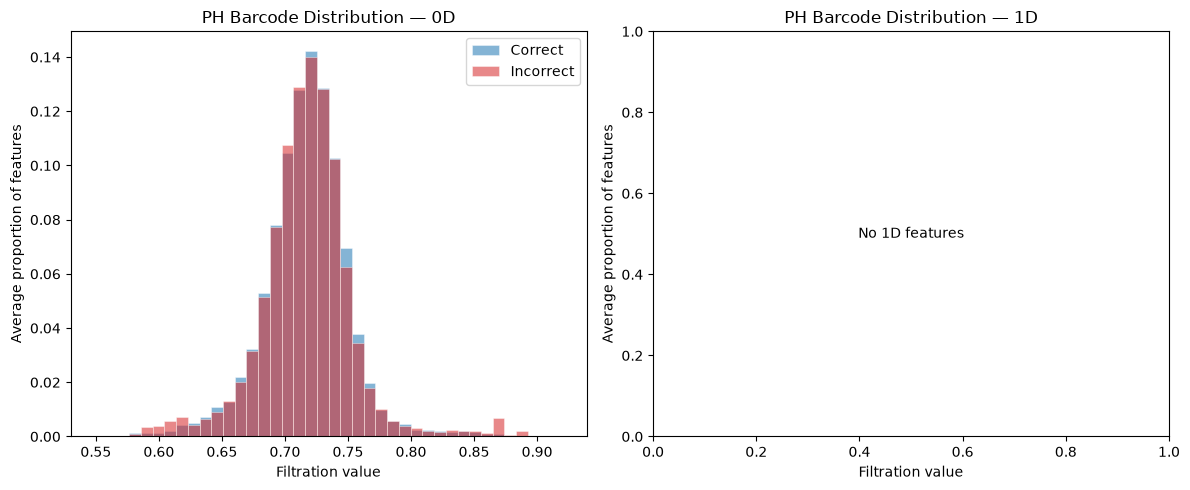

model:  ['Qwen 3 8B', 'Qwen/Qwen3-8B', 'qwen']
dataset:  ['mmlu_math', '~/TDA_RI/TDA_reason-interpret/datasets/mmlu_math.csv']
Sampling 100 correct and 100 incorrect examples
+--------------------+---------------------+-----------------------+-----------------------+------------------------+---------------------+---------------------+
|       label        |       num_feat      |        max_feat       | max_feat_minus_second |       mean_feat        |     betti_curve     | persistence_entropy |
+--------------------+---------------------+-----------------------+-----------------------+------------------------+---------------------+---------------------+
|    correct_0dim    |        66.48        |   0.843248291015625   |   0.0180133056640625  |   0.7407483949234377   |        57.869       |   4.13464164785562  |
| correct_0dim_stdv  |  2.4159603983643123 | 0.0025717988849907705 | 0.0018069085930772885 | 0.0011890981783968728  |  2.100287183345471  | 0.03461981065299917 |
|    correct_1d

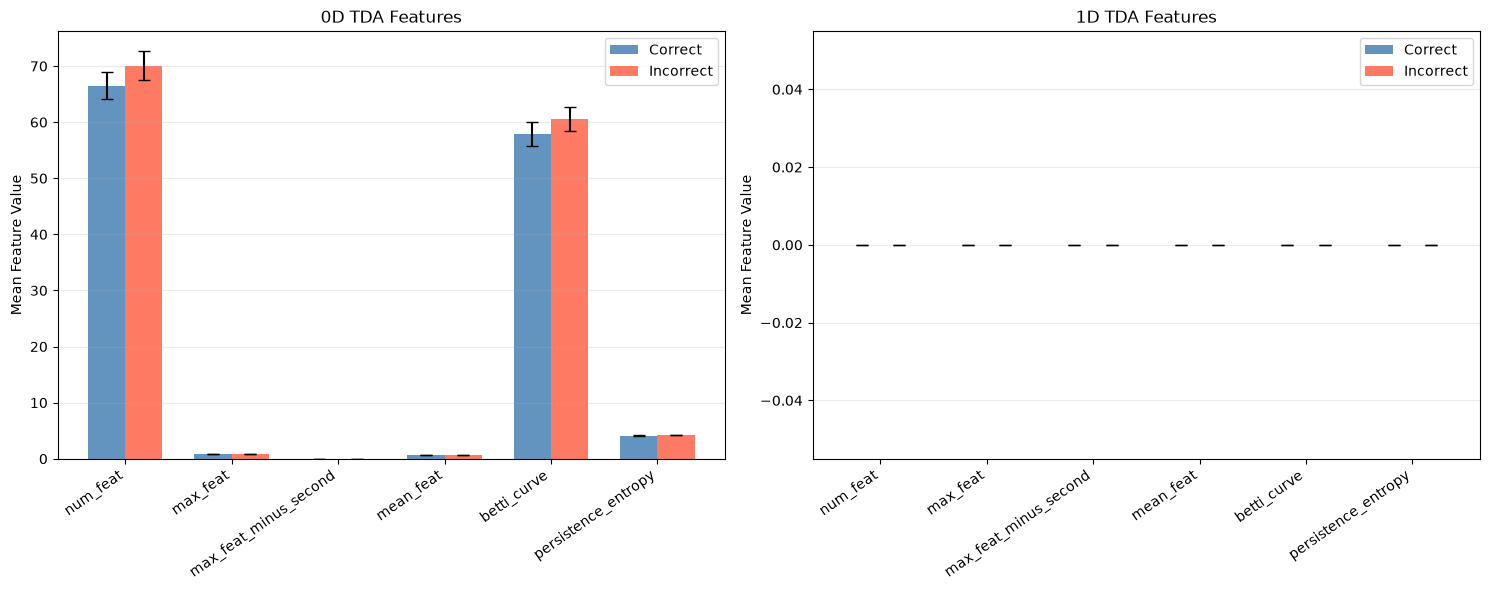

Sampling 100 correct and 100 incorrect examples
Correct samples 0 dim: 100
Incorrect samples 0 dim: 100
Correct samples 1 dim: 0
Incorrect samples 1 dim: 0
Filtration range 0 dim: 0.55859375 0.92236328
Filtration range 1 dim: None None


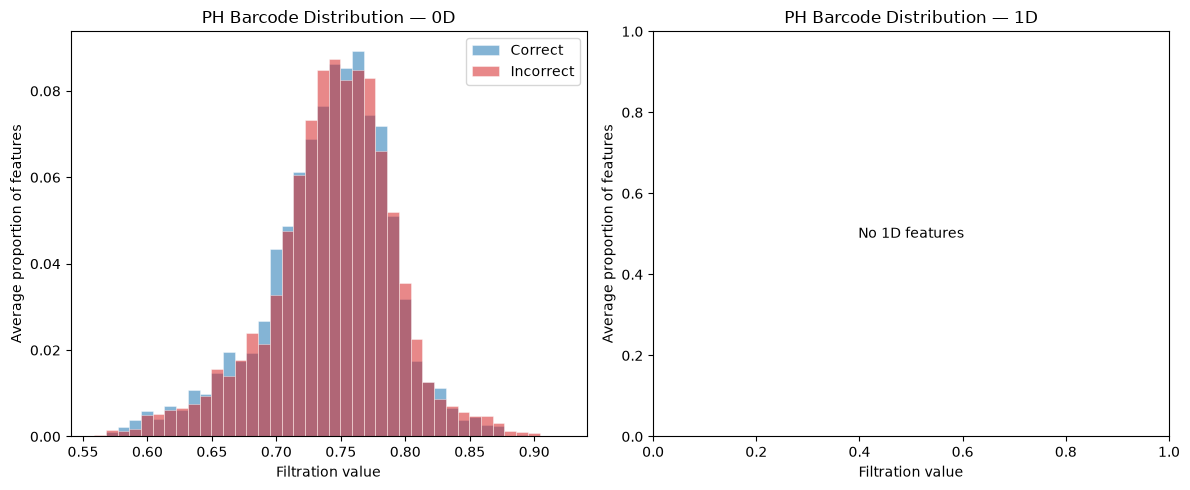

model:  ['Qwen 3 8B', 'Qwen/Qwen3-8B', 'qwen']
dataset:  ['mmlu_misc', '~/TDA_RI/TDA_reason-interpret/datasets/mmlu_misc.csv']
Sampling 100 correct and 100 incorrect examples
+--------------------+--------------------+-----------------------+------------------------+------------------------+--------------------+----------------------+
|       label        |      num_feat      |        max_feat       | max_feat_minus_second  |       mean_feat        |    betti_curve     | persistence_entropy  |
+--------------------+--------------------+-----------------------+------------------------+------------------------+--------------------+----------------------+
|    correct_0dim    |       47.29        |   0.8207794189453125  |   0.0120013427734375   |   0.7020047578404207   |      40.1704       |  3.757312496016856   |
| correct_0dim_stdv  | 2.5054000265285565 |  0.002084310687986892 | 0.0012556407357677503  |  0.00157024986568679   | 2.154696172165216  | 0.04075703422974668  |
|    correct_1d

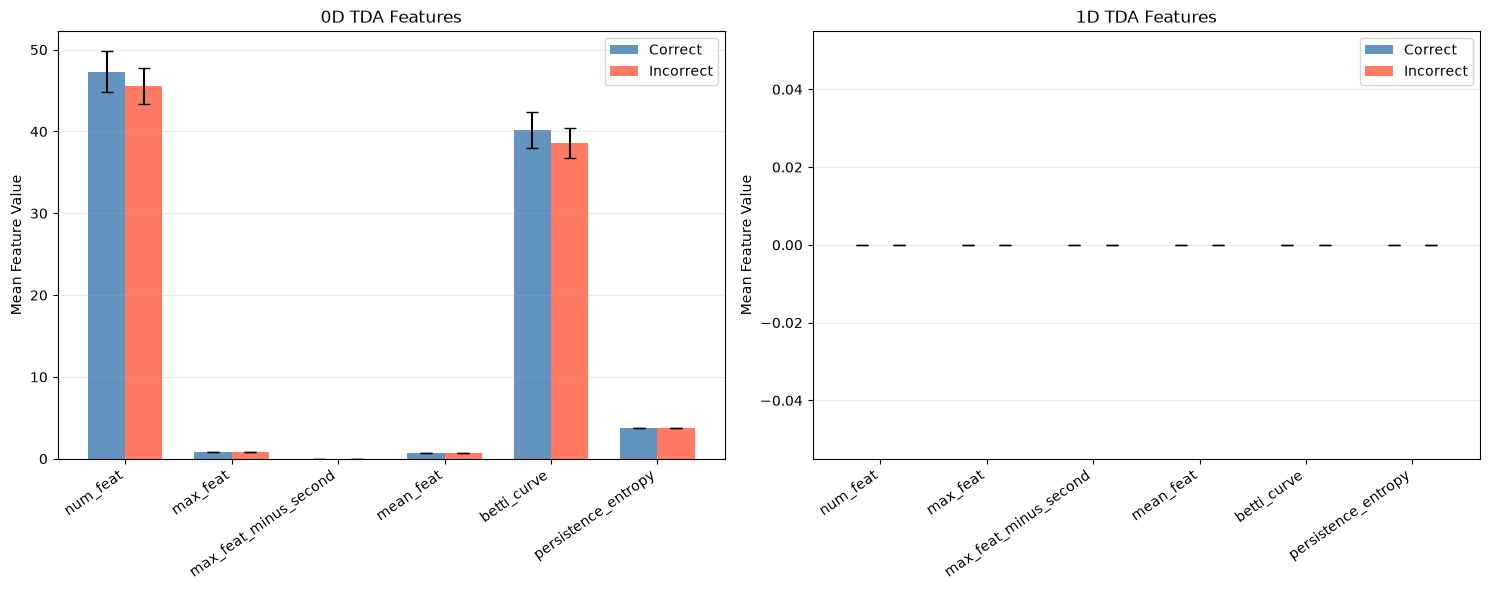

Sampling 100 correct and 100 incorrect examples
Correct samples 0 dim: 100
Incorrect samples 0 dim: 100
Correct samples 1 dim: 0
Incorrect samples 1 dim: 0
Filtration range 0 dim: 0.55053711 0.90765381
Filtration range 1 dim: None None


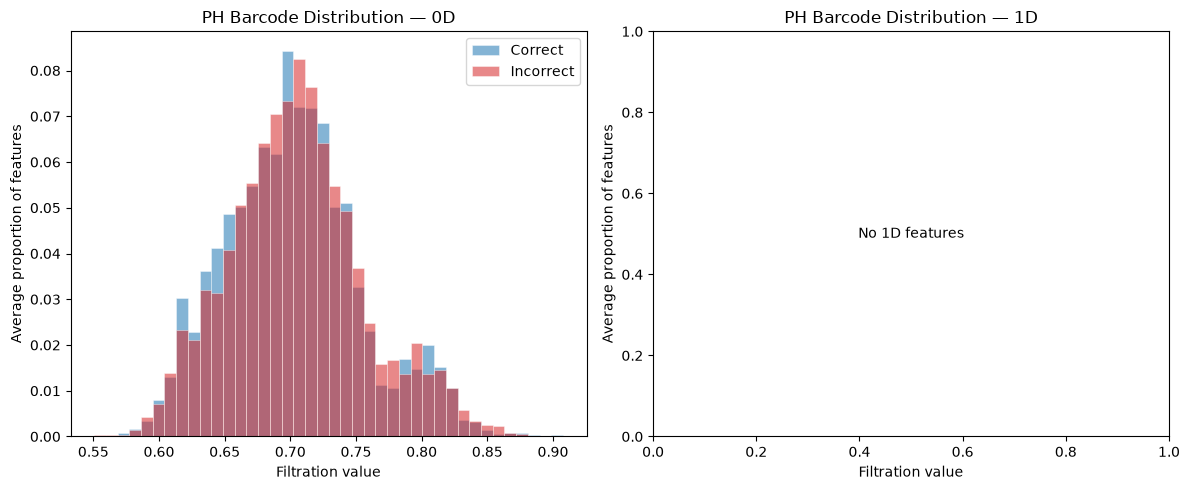

model:  ['Qwen 3 8B', 'Qwen/Qwen3-8B', 'qwen']
dataset:  ['mmlu_moral', '~/TDA_RI/TDA_reason-interpret/datasets/mmlu_moral.csv']
Sampling 100 correct and 100 incorrect examples
+--------------------+---------------------+------------------------+-----------------------+------------------------+---------------------+-----------------------+
|       label        |       num_feat      |        max_feat        | max_feat_minus_second |       mean_feat        |     betti_curve     |  persistence_entropy  |
+--------------------+---------------------+------------------------+-----------------------+------------------------+---------------------+-----------------------+
|    correct_0dim    |        103.58       |   0.864642333984375    |    0.02205810546875   |   0.7173157917362201   |        85.24        |   4.6363515649271445  |
| correct_0dim_stdv  |  0.6795988121344427 | 4.733728507547979e-05  | 0.0011162668390108665 |  0.00014231464941911   |  0.5580771461098376 |  0.006435086742129286 

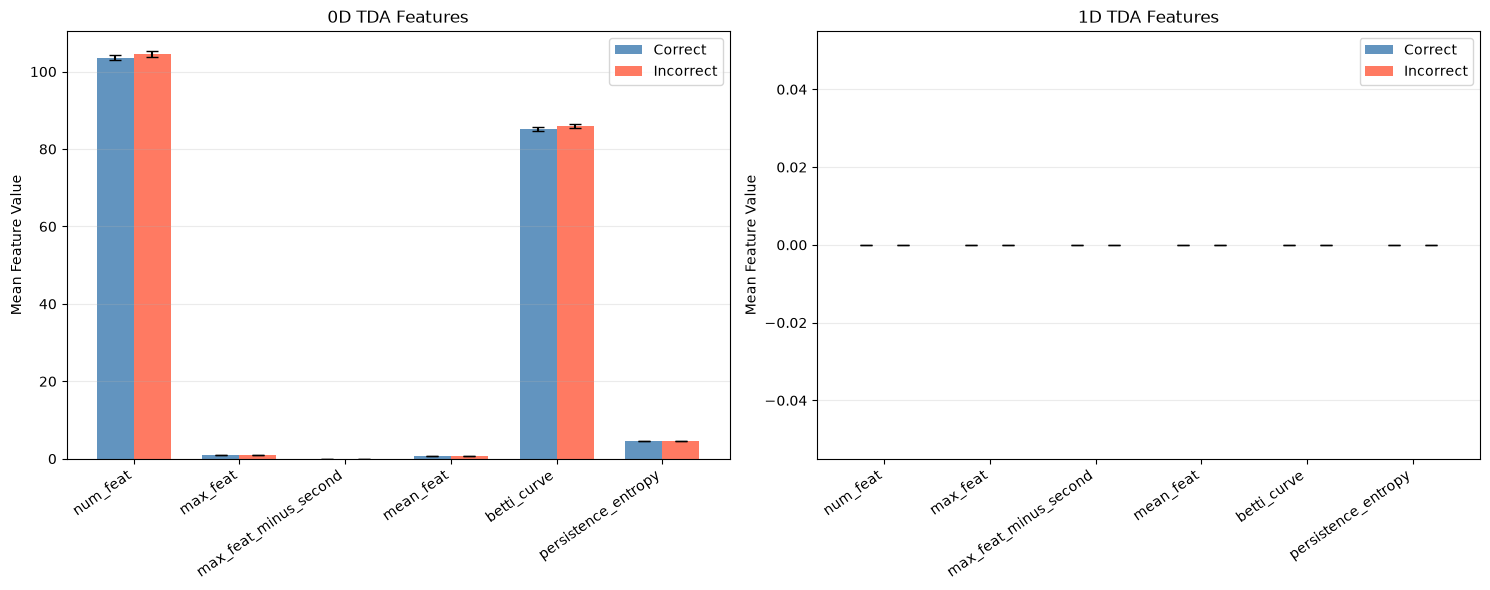

Sampling 100 correct and 100 incorrect examples
Correct samples 0 dim: 100
Incorrect samples 0 dim: 100
Correct samples 1 dim: 0
Incorrect samples 1 dim: 0
Filtration range 0 dim: 0.59399414 0.88116455
Filtration range 1 dim: None None


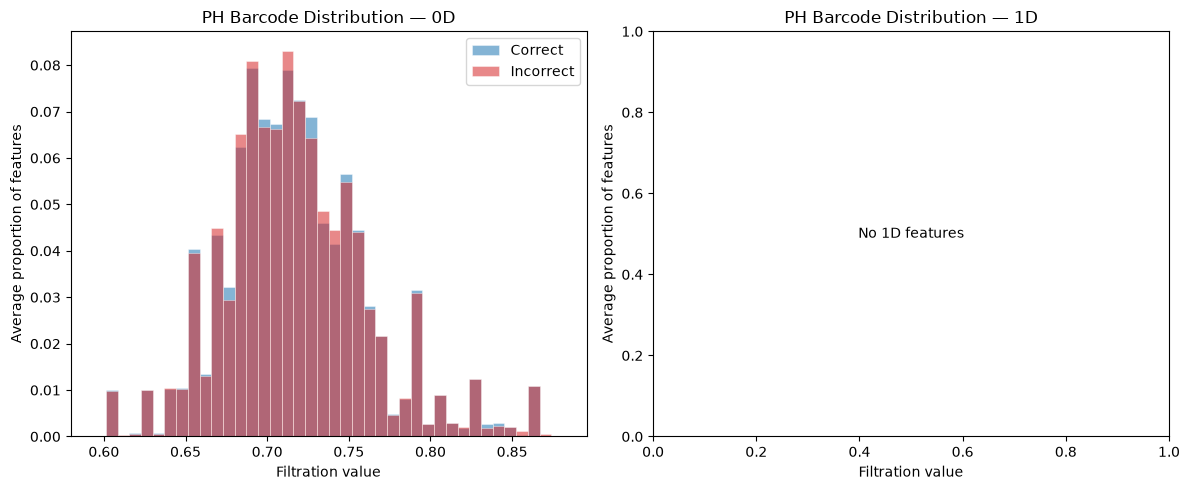

model:  ['Qwen 3 8B', 'Qwen/Qwen3-8B', 'qwen']
dataset:  ['mmlu_psych', '~/TDA_RI/TDA_reason-interpret/datasets/mmlu_psych.csv']
Sampling 100 correct and 100 incorrect examples
+--------------------+--------------------+-----------------------+------------------------+-------------------------+--------------------+----------------------+
|       label        |      num_feat      |        max_feat       | max_feat_minus_second  |        mean_feat        |    betti_curve     | persistence_entropy  |
+--------------------+--------------------+-----------------------+------------------------+-------------------------+--------------------+----------------------+
|    correct_0dim    |       77.67        |   0.817982177734375   |   0.016617431640625    |    0.7073471437849653   |      66.6576       |   4.27989805865511   |
| correct_0dim_stdv  | 3.0811271386368406 |  0.002495793801292421 | 0.0014095856967081659  |   0.000933381766700793  | 2.6235113840466218 | 0.037481737392936185 |
|    cor

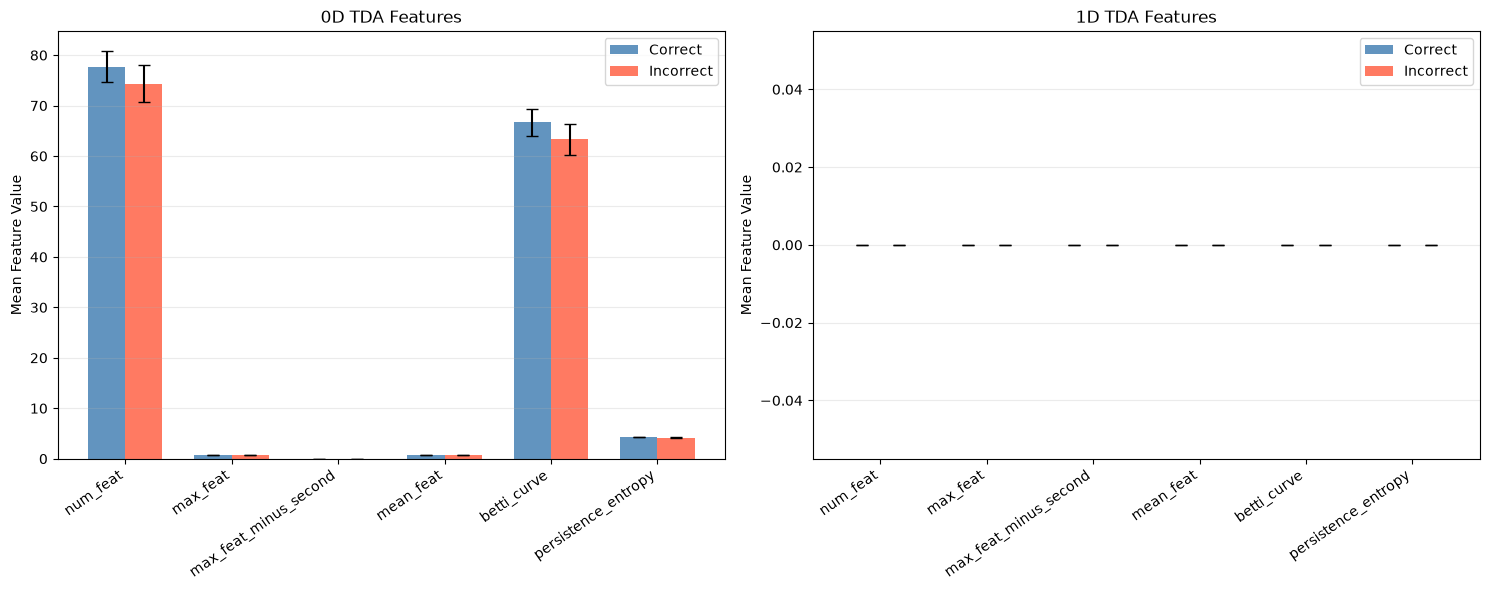

Sampling 100 correct and 100 incorrect examples
Correct samples 0 dim: 100
Incorrect samples 0 dim: 100
Correct samples 1 dim: 0
Incorrect samples 1 dim: 0
Filtration range 0 dim: 0.55297852 0.89349365
Filtration range 1 dim: None None


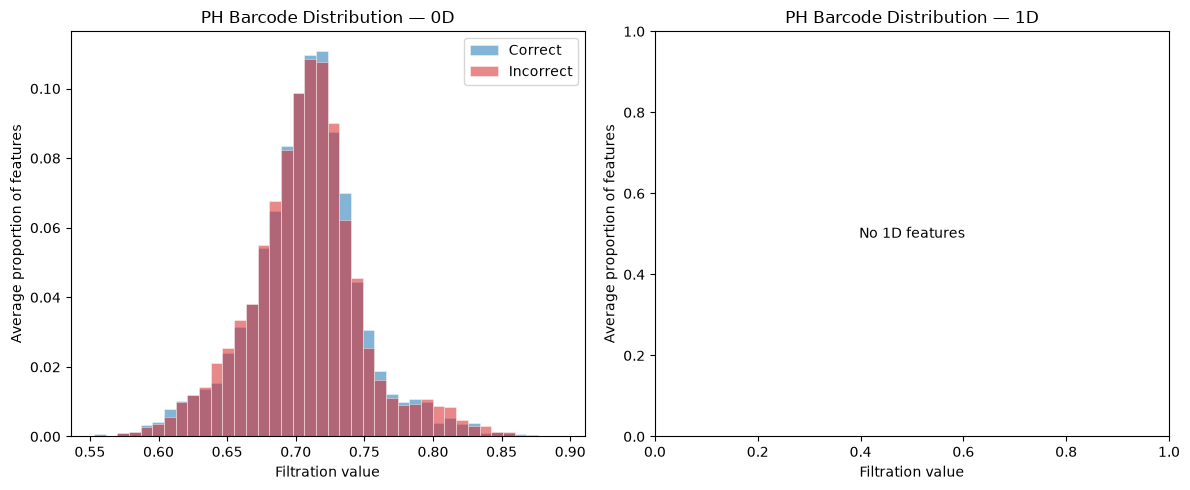

model:  ['Mistral 7B v0.3', 'mistralai/Mistral-7B-v0.3', 'mistral']
dataset:  ['hellaswag', '~/TDA_RI/TDA_reason-interpret/datasets/hellaswag.csv']
Sampling 100 correct and 100 incorrect examples
+--------------------+---------------------+------------------------+------------------------+------------------------+----------------------+-----------------------+
|       label        |       num_feat      |        max_feat        | max_feat_minus_second  |       mean_feat        |     betti_curve      |  persistence_entropy  |
+--------------------+---------------------+------------------------+------------------------+------------------------+----------------------+-----------------------+
|    correct_0dim    |        137.98       |   0.8980227661132812   |  0.00769073486328125   |   0.7745049656786251   |  117.80840000000003  |   4.8089347916548535  |
| correct_0dim_stdv  |  6.948104603109944  | 0.0015407096508705312  | 0.0007371201400024665  | 0.0012254835623550107  |  5.8707003431955

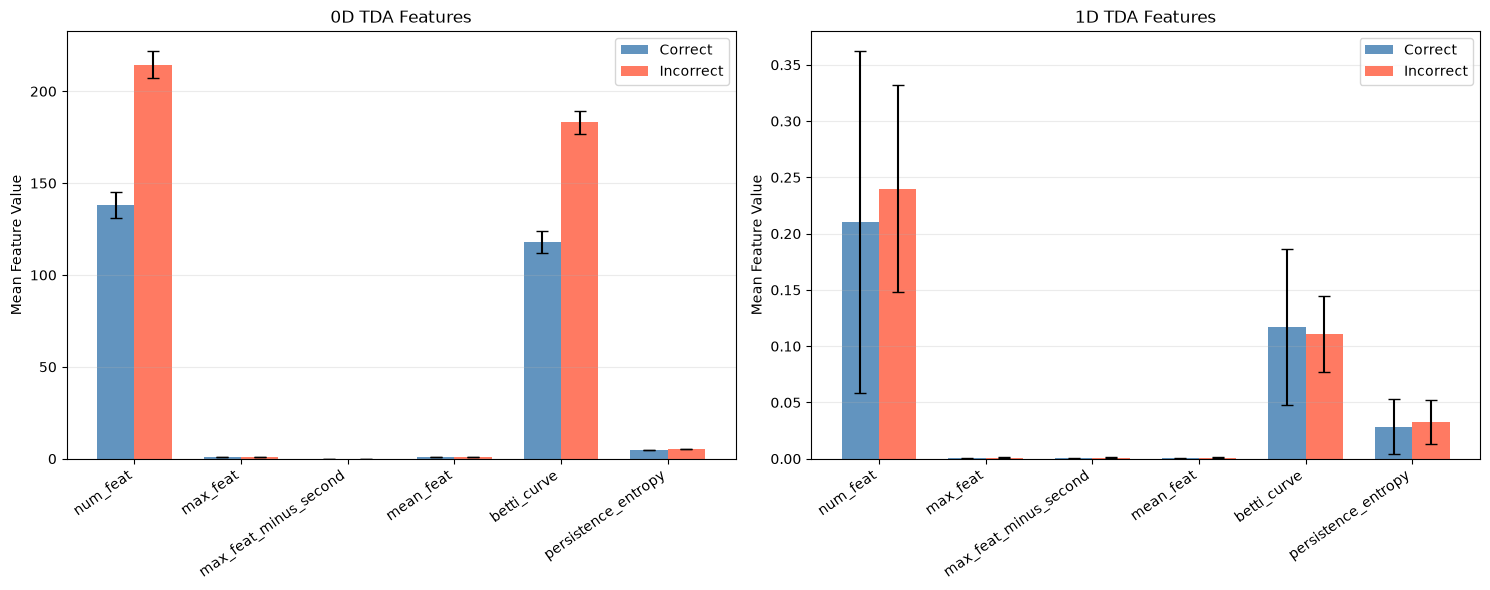

Sampling 100 correct and 100 incorrect examples
Correct samples 0 dim: 100
Incorrect samples 0 dim: 100
Correct samples 1 dim: 6
Incorrect samples 1 dim: 13
Filtration range 0 dim: 0.52392578 0.94424438
Filtration range 1 dim: 0.91137695 0.98362732


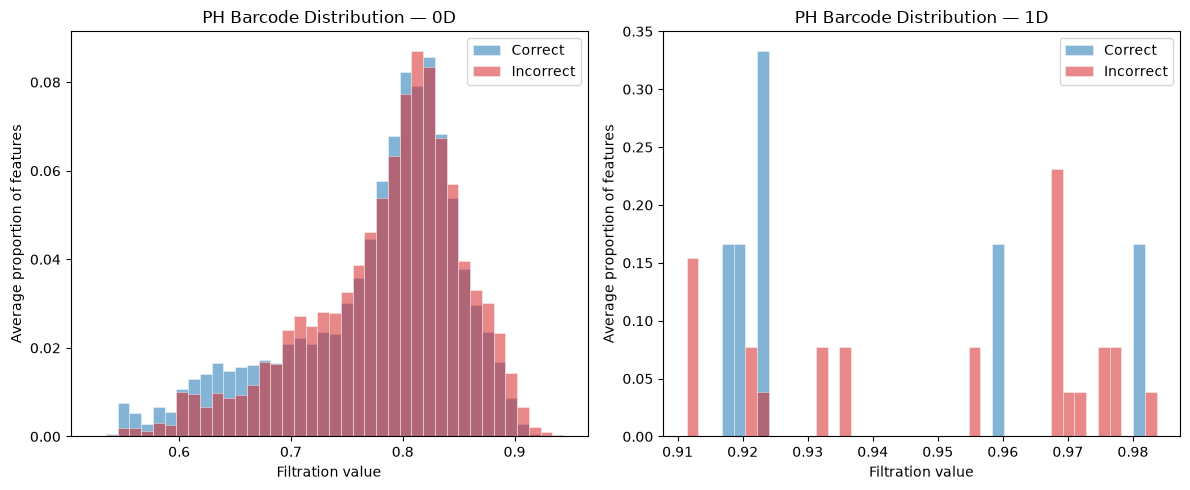

model:  ['Mistral 7B v0.3', 'mistralai/Mistral-7B-v0.3', 'mistral']
dataset:  ['mmlu_law', '~/TDA_RI/TDA_reason-interpret/datasets/mmlu_law.csv']
Sampling 100 correct and 100 incorrect examples
+--------------------+---------------------+------------------------+-----------------------+------------------------+----------------------+----------------------+
|       label        |       num_feat      |        max_feat        | max_feat_minus_second |       mean_feat        |     betti_curve      | persistence_entropy  |
+--------------------+---------------------+------------------------+-----------------------+------------------------+----------------------+----------------------+
|    correct_0dim    |        273.77       |   0.9166482543945312   |  0.01151519775390625  |   0.7603609042767399   |  224.97479999999996  |  5.521887803325538   |
| correct_0dim_stdv  |  9.925844797773888  |  0.001695123743958316  | 0.0009011042841555407 | 0.0013509219162974719  |  8.184186385803768   | 0.04

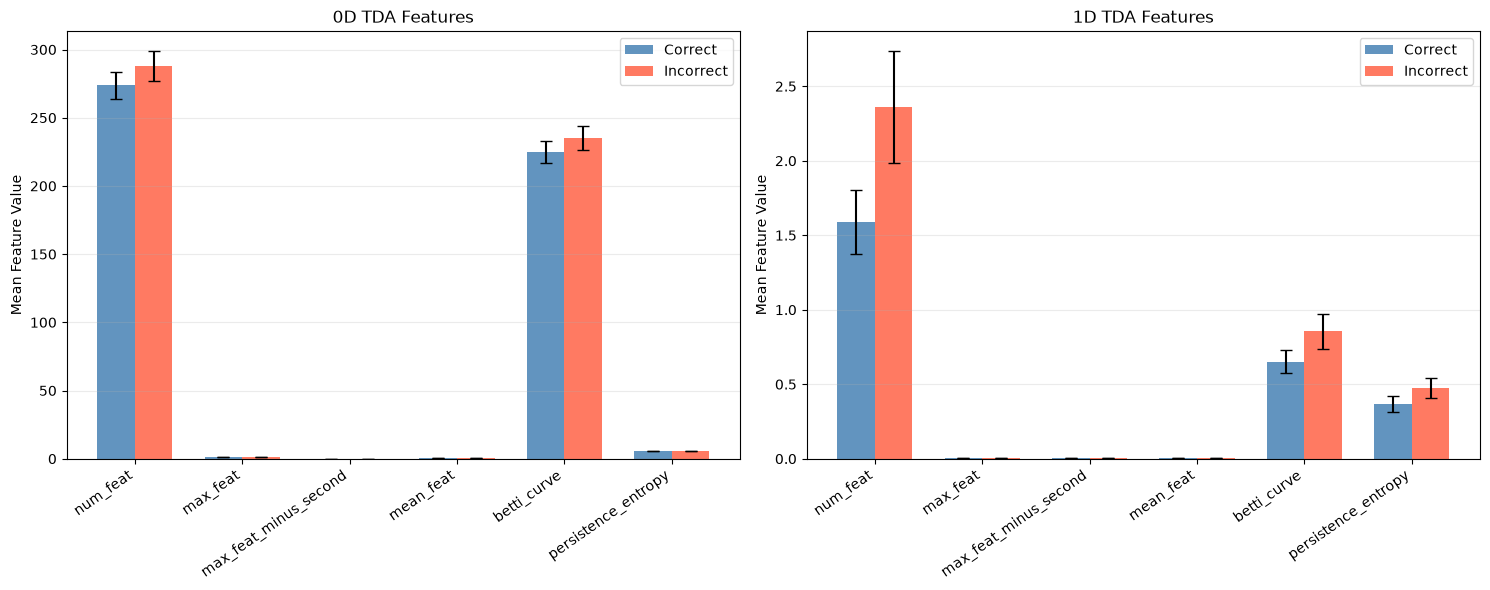

Sampling 100 correct and 100 incorrect examples
Correct samples 0 dim: 100
Incorrect samples 0 dim: 100
Correct samples 1 dim: 55
Incorrect samples 1 dim: 62
Filtration range 0 dim: 0.53271484 0.95217896
Filtration range 1 dim: 0.91748047 0.98965454


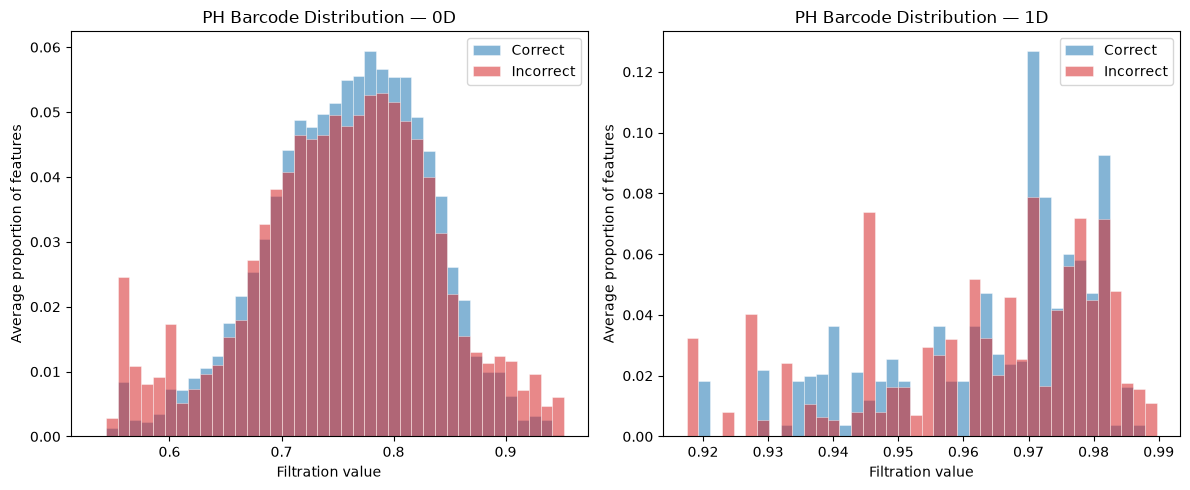

model:  ['Mistral 7B v0.3', 'mistralai/Mistral-7B-v0.3', 'mistral']
dataset:  ['mmlu_math', '~/TDA_RI/TDA_reason-interpret/datasets/mmlu_math.csv']
Sampling 97 correct and 100 incorrect examples
+--------------------+-----------------------+-------------------------+------------------------+-------------------------+-----------------------+------------------------+
|       label        |        num_feat       |         max_feat        | max_feat_minus_second  |        mean_feat        |      betti_curve      |  persistence_entropy   |
+--------------------+-----------------------+-------------------------+------------------------+-------------------------+-----------------------+------------------------+
|    correct_0dim    |   69.96907216494846   |    0.8761514879993557   |  0.006555930855347938  |    0.7644639230788275   |   60.40247422680412   |   4.178141952255661    |
| correct_0dim_stdv  |    2.66094694828085   |  0.0014741004360410987  | 0.0006321332089139617  |   0.00167404474

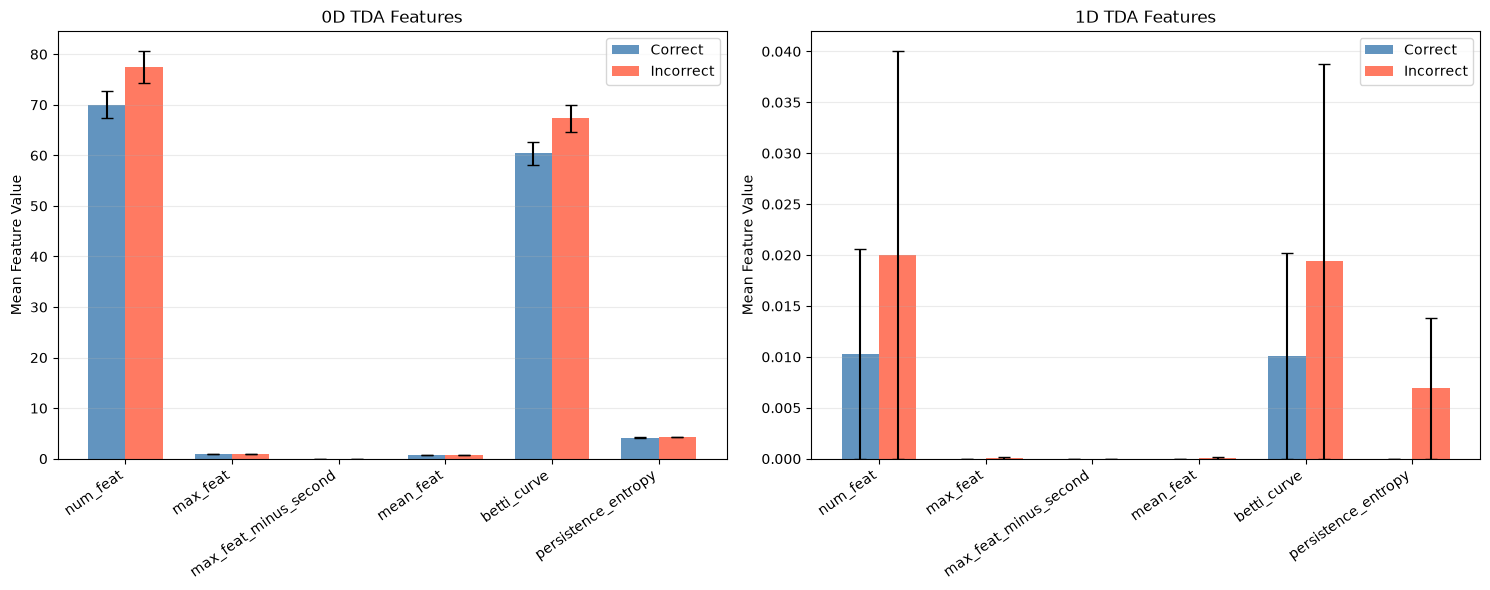

Sampling 97 correct and 100 incorrect examples
Correct samples 0 dim: 97
Incorrect samples 0 dim: 100
Correct samples 1 dim: 1
Incorrect samples 1 dim: 1
Filtration range 0 dim: 0.53417969 0.91790771
Filtration range 1 dim: 0.92883301 0.9609375


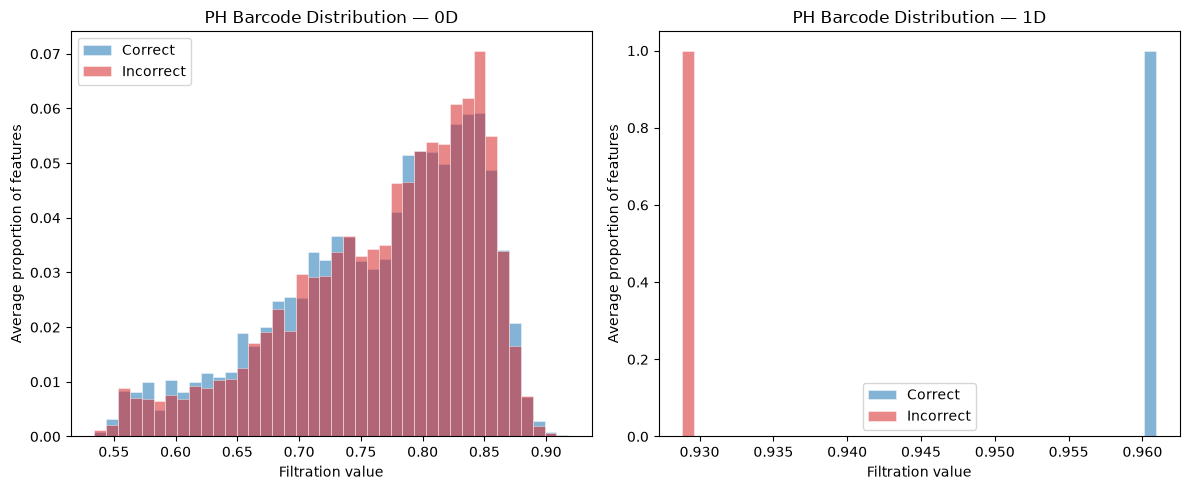

model:  ['Mistral 7B v0.3', 'mistralai/Mistral-7B-v0.3', 'mistral']
dataset:  ['mmlu_misc', '~/TDA_RI/TDA_reason-interpret/datasets/mmlu_misc.csv']
Sampling 100 correct and 100 incorrect examples
+--------------------+---------------------+------------------------+------------------------+-----------------------+---------------------+----------------------+
|       label        |       num_feat      |        max_feat        | max_feat_minus_second  |       mean_feat       |     betti_curve     | persistence_entropy  |
+--------------------+---------------------+------------------------+------------------------+-----------------------+---------------------+----------------------+
|    correct_0dim    |         50.2        |   0.862325439453125    |   0.006224365234375    |   0.7372141976376075  |       42.4554       |  3.8522133240135257  |
| correct_0dim_stdv  |  2.0570155884954135 | 0.0015411286233336814  | 0.0006724121445815023  | 0.0013626992527673457 |  1.696246381355794  | 0.03150

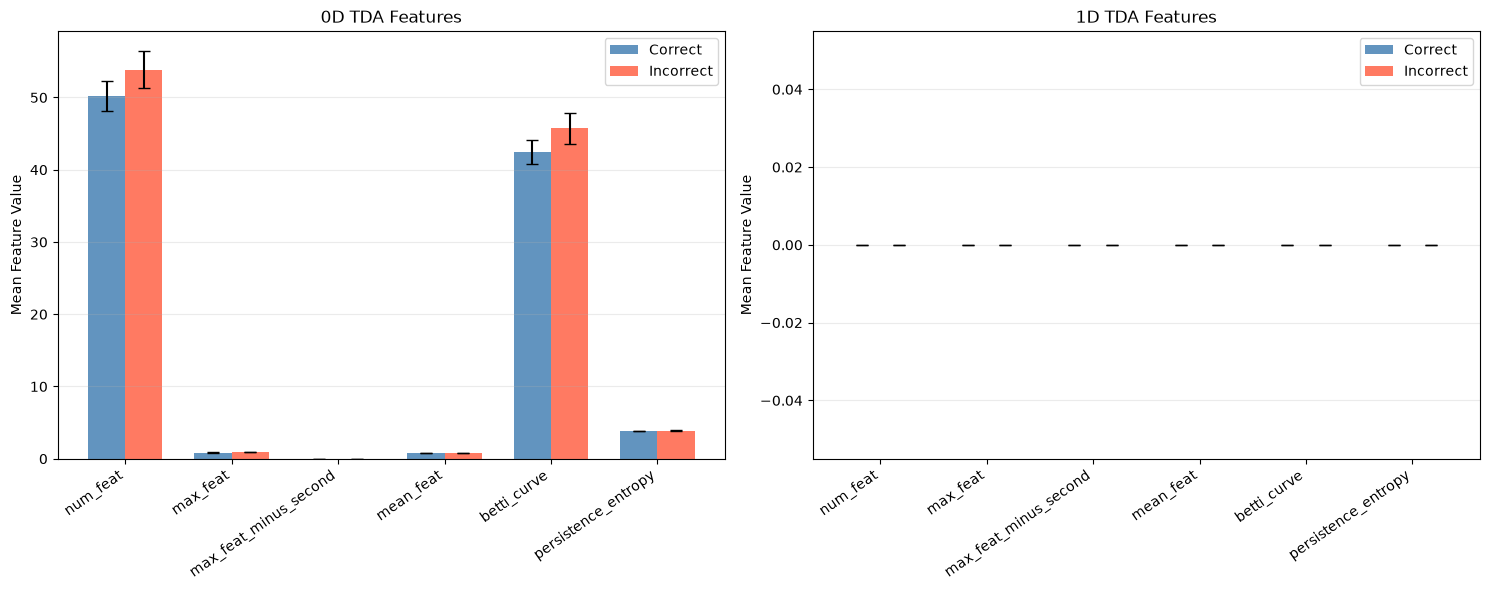

Sampling 100 correct and 100 incorrect examples
Correct samples 0 dim: 100
Incorrect samples 0 dim: 100
Correct samples 1 dim: 0
Incorrect samples 1 dim: 0
Filtration range 0 dim: 0.5300293 0.92004395
Filtration range 1 dim: None None


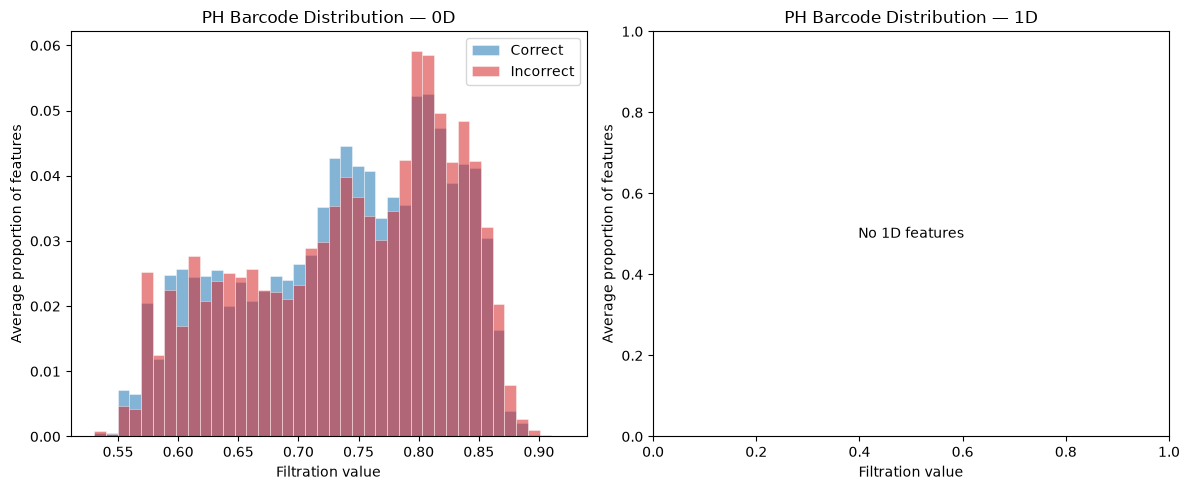

model:  ['Mistral 7B v0.3', 'mistralai/Mistral-7B-v0.3', 'mistral']
dataset:  ['mmlu_moral', '~/TDA_RI/TDA_reason-interpret/datasets/mmlu_moral.csv']
Sampling 100 correct and 100 incorrect examples
+--------------------+---------------------+-------------------------+------------------------+-------------------------+----------------------+-----------------------+
|       label        |       num_feat      |         max_feat        | max_feat_minus_second  |        mean_feat        |     betti_curve      |  persistence_entropy  |
+--------------------+---------------------+-------------------------+------------------------+-------------------------+----------------------+-----------------------+
|    correct_0dim    |        118.7        |    0.9178070068359375   |    0.01770263671875    |    0.7463344165834301   |  95.75540000000001   |   4.7684530033202295  |
| correct_0dim_stdv  |  0.8138324350400593 |  0.0006577678221210911  | 0.0008286638820321667  |  0.0002428627695989611  |  0.6

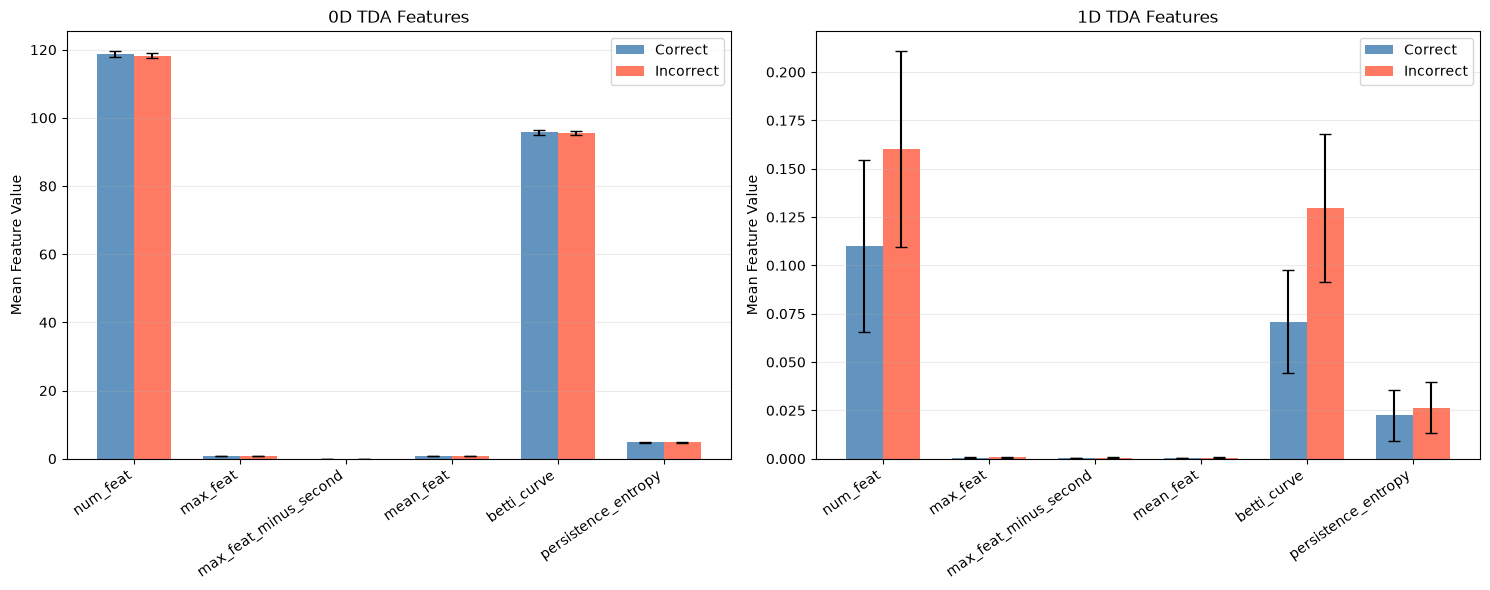

Sampling 100 correct and 100 incorrect examples
Correct samples 0 dim: 100
Incorrect samples 0 dim: 100
Correct samples 1 dim: 7
Incorrect samples 1 dim: 11
Filtration range 0 dim: 0.56860352 0.93481445
Filtration range 1 dim: 0.92877197 0.97296143


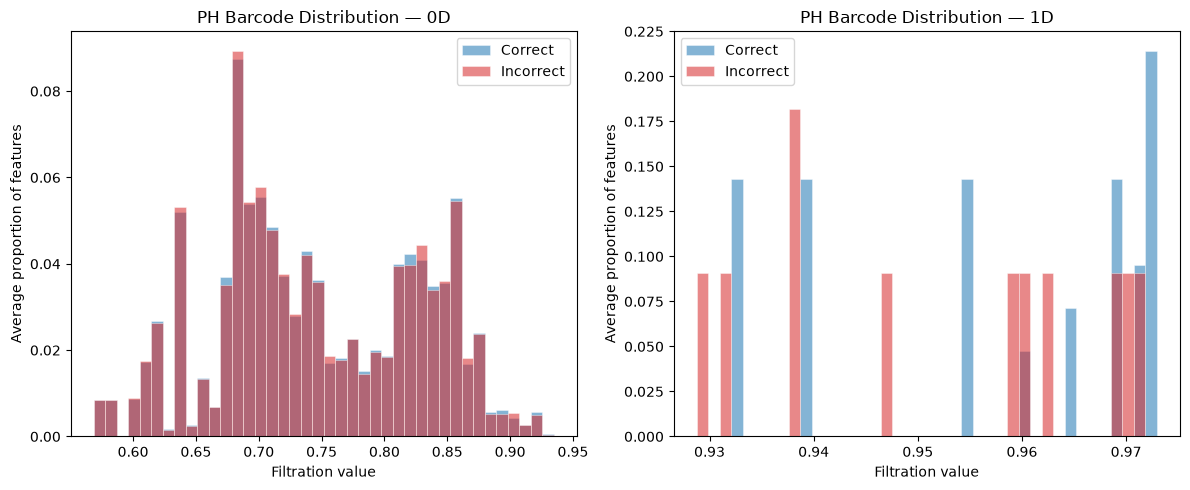

model:  ['Mistral 7B v0.3', 'mistralai/Mistral-7B-v0.3', 'mistral']
dataset:  ['mmlu_psych', '~/TDA_RI/TDA_reason-interpret/datasets/mmlu_psych.csv']
Sampling 100 correct and 100 incorrect examples
+--------------------+-----------------------+------------------------+------------------------+-------------------------+-----------------------+-----------------------+
|       label        |        num_feat       |        max_feat        | max_feat_minus_second  |        mean_feat        |      betti_curve      |  persistence_entropy  |
+--------------------+-----------------------+------------------------+------------------------+-------------------------+-----------------------+-----------------------+
|    correct_0dim    |         86.39         |   0.8870138549804687   |  0.00857940673828125   |    0.7475771329115685   |   72.26880000000001   |   4.377428250499401   |
| correct_0dim_stdv  |   3.767803395115306   | 0.0017569200932201095  | 0.0007758957307616121  |  0.001935478191410477

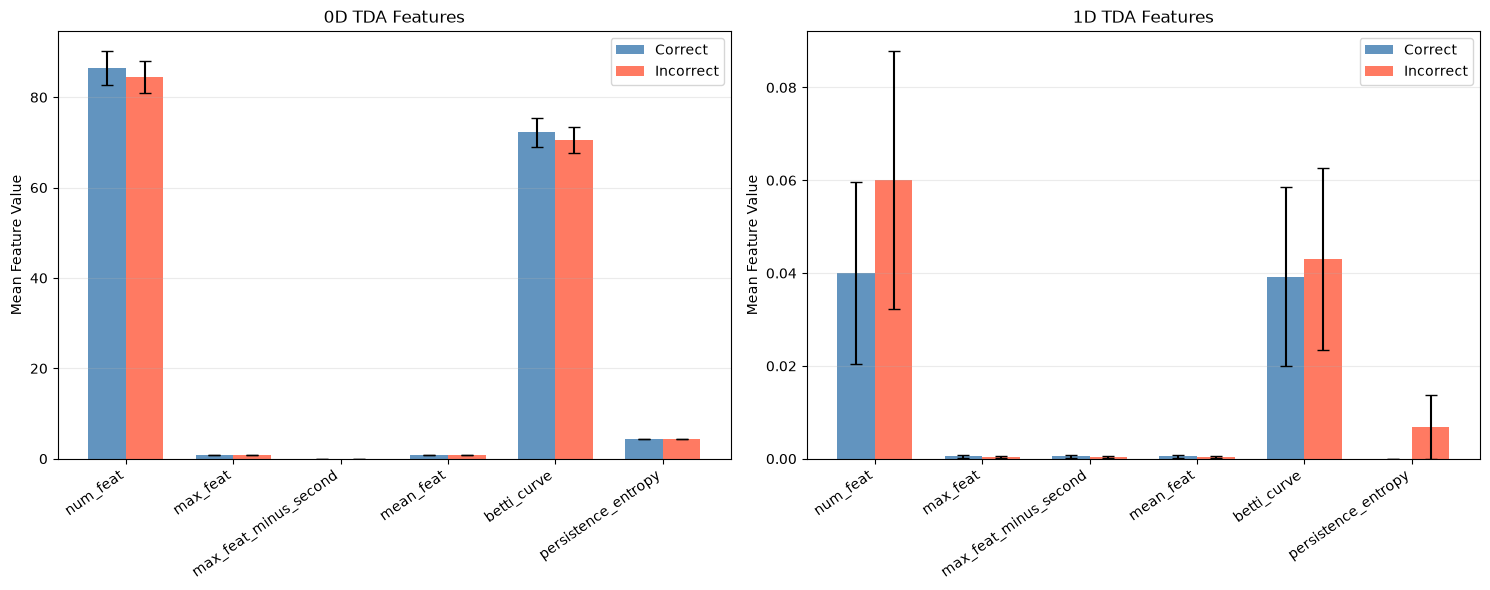

Sampling 100 correct and 100 incorrect examples
Correct samples 0 dim: 100
Incorrect samples 0 dim: 100
Correct samples 1 dim: 4
Incorrect samples 1 dim: 5
Filtration range 0 dim: 0.52905273 0.93978882
Filtration range 1 dim: 0.95346069 0.97492981


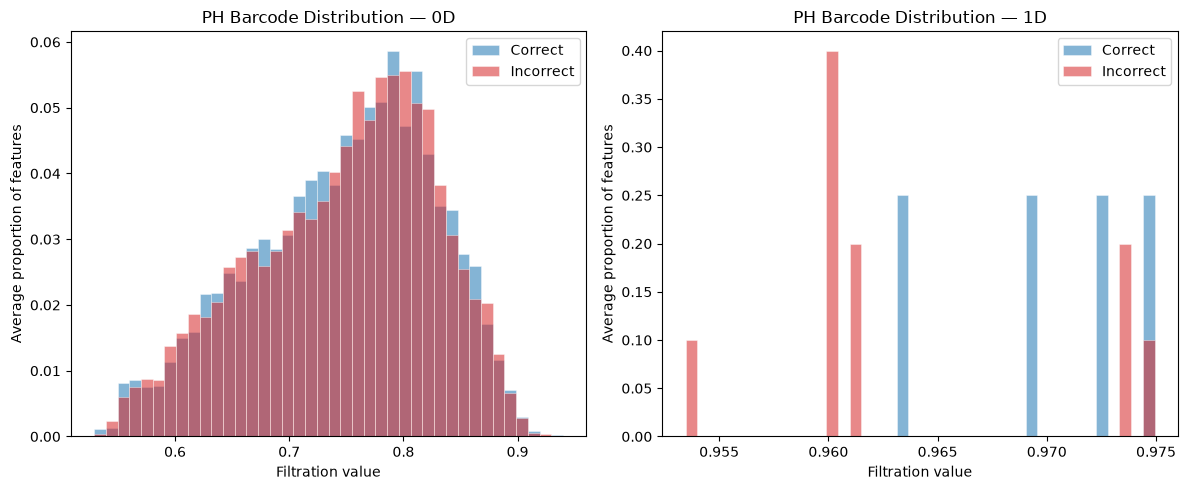

In [6]:
for model in models:
    for dataset in datasets[:6]:
        print("model: ", model)
        print("dataset: ", dataset)
        topo.analyze_feats(model, dataset, False)
        topo.plot_barcode(model, dataset)

Sampling 1 correct and 1 incorrect examples
Sampling 100 correct and 100 incorrect examples
corr parsed count:  100
incorr parsed count:  100


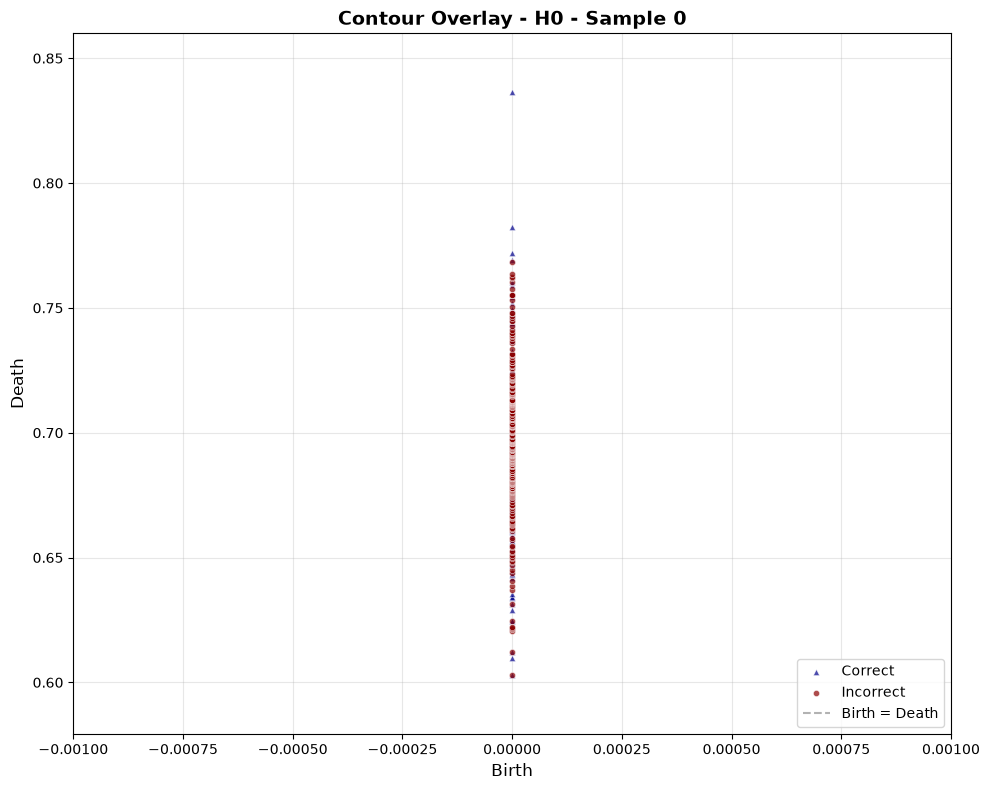

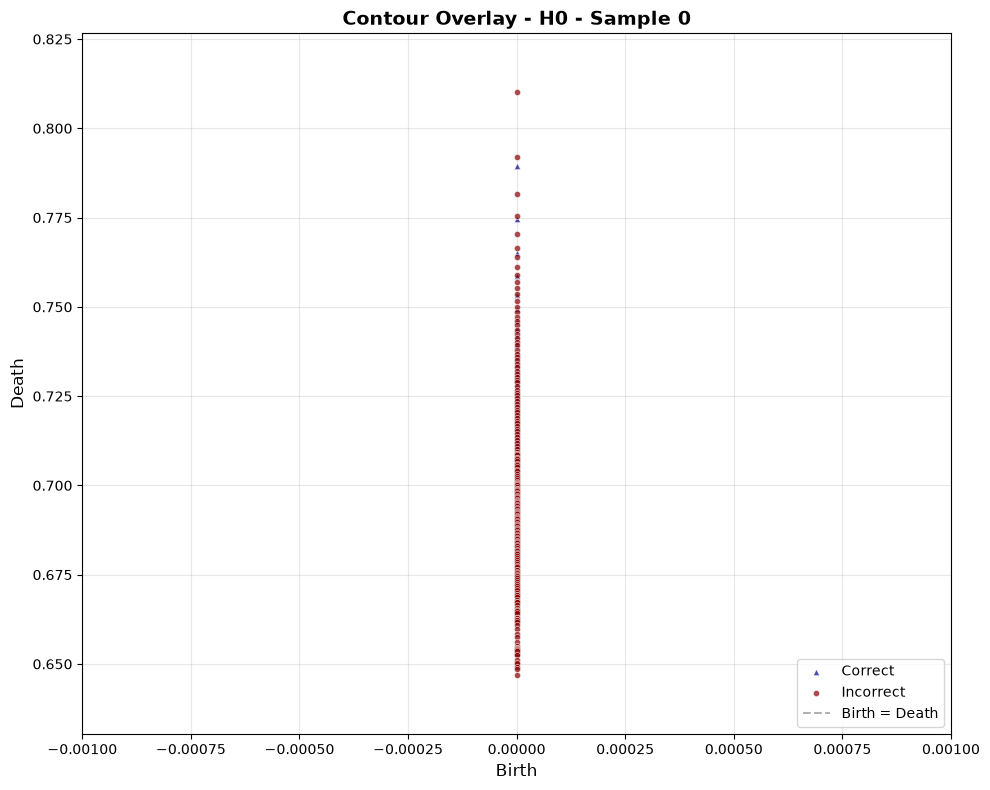

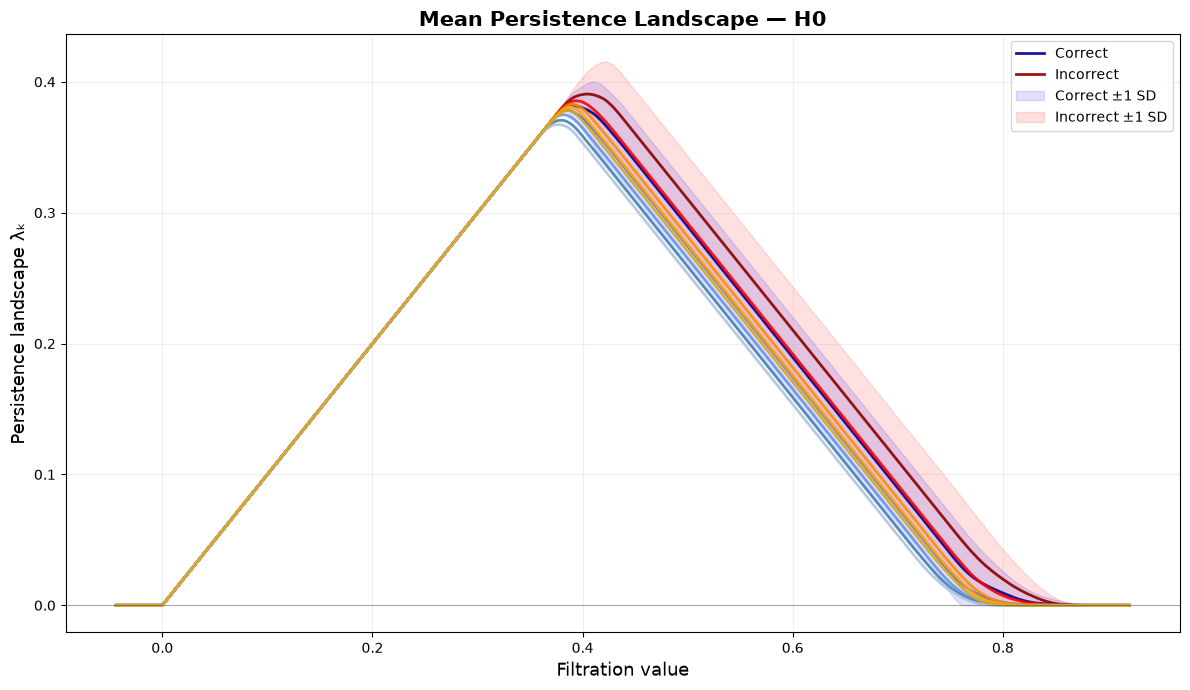

{'x': array([-4.38262940e-02, -4.18940726e-02, -3.99618512e-02, -3.80296299e-02,
        -3.60974085e-02, -3.41651871e-02, -3.22329657e-02, -3.03007443e-02,
        -2.83685230e-02, -2.64363016e-02, -2.45040802e-02, -2.25718588e-02,
        -2.06396375e-02, -1.87074161e-02, -1.67751947e-02, -1.48429733e-02,
        -1.29107519e-02, -1.09785306e-02, -9.04630918e-03, -7.11408780e-03,
        -5.18186642e-03, -3.24964505e-03, -1.31742367e-03,  6.14797711e-04,
         2.54701909e-03,  4.47924047e-03,  6.41146185e-03,  8.34368323e-03,
         1.02759046e-02,  1.22081260e-02,  1.41403474e-02,  1.60725687e-02,
         1.80047901e-02,  1.99370115e-02,  2.18692329e-02,  2.38014543e-02,
         2.57336756e-02,  2.76658970e-02,  2.95981184e-02,  3.15303398e-02,
         3.34625612e-02,  3.53947825e-02,  3.73270039e-02,  3.92592253e-02,
         4.11914467e-02,  4.31236680e-02,  4.50558894e-02,  4.69881108e-02,
         4.89203322e-02,  5.08525536e-02,  5.27847749e-02,  5.47169963e-02,
       

In [7]:
# correct_1, incorrect_1 = topo.rand_sample(models[0], datasets[0], n=1)
# correct_100, incorrect_100 = topo.rand_sample(models[0], datasets[0], n=100)

# correct_dim1 = topo.parse_diagram_string(correct_1["diagrams"].iloc[0])
# incorrect_dim1 = topo.parse_diagram_string(incorrect_1["diagrams"].iloc[0])

# # print("corr: ", correct_dim1)
# # print("incorr: ", incorrect_dim1)

# correct_d100 = correct_100["diagrams"]
# incorrect_d100 = incorrect_100["diagrams"]

# correct_dim100 = [topo.parse_diagram_string(x) for x in correct_d100 ]
# incorrect_dim100 = [topo.parse_diagram_string(x) for x in incorrect_d100]

# avg_correct_dim100 = cont.average_barcode(correct_dim100, dim=0)
# avg_incorrect_dim100 = cont.average_barcode(incorrect_dim100, dim=0)

# print("corr: ", correct_dim100)
# print("incorr: ", incorrect_dim100)

correct_1, incorrect_1 = topo.rand_sample(models[0], datasets[0], n=1)
correct_100, incorrect_100 = topo.rand_sample(models[0], datasets[0], n=100)

# 1. Fixed variable names (matching your definition: correct_dim1)
correct_dim1 = topo.parse_diagram_string(correct_1["diagrams"].iloc[0])
incorrect_dim1 = topo.parse_diagram_string(incorrect_1["diagrams"].iloc[0])

correct_d100 = correct_100["diagrams"]
incorrect_d100 = incorrect_100["diagrams"]

correct_dim100 = [topo.parse_diagram_string(x) for x in correct_d100]
incorrect_dim100 = [topo.parse_diagram_string(x) for x in incorrect_d100]

# Compute average barcodes (returns mean, std, counts tuple)
avg_correct_dim100 = cont.average_barcode(correct_dim100, dim=0)
avg_incorrect_dim100 = cont.average_barcode(incorrect_dim100, dim=0)

print("corr parsed count: ", len(correct_dim100))
print("incorr parsed count: ", len(incorrect_dim100))

cont.plot_contour_overlay(correct_dim1, incorrect_dim1, dim=0)
cont.plot_contour_overlay(avg_correct_dim100, avg_incorrect_dim100, dim=0)
cont.plot_mean_persistence_landscape(correct_dim100, incorrect_dim100, dim=0)

In [ ]:
# get heatmap!
ling.make_heatmap(datasets[0], models[0], linguistic_labels[0], tda_labels[0])

AttributeError: module 'analysis_functions' has no attribute 'get_ling_feat'

: 

: 

In [ ]:
# test pval corr matrix
# choose model and dataset
model_index2 = [1, 2, 5, 6]
data_index2 = [1, 1, 4, 4]
# model_id =  models[8]
# dataset = datasets[3]

# choose linguistic labels :0
tda_label2 = tda_labels[0]

# get heatmap!
for i in range(0,4):
    cor_heat = make_heatmap(datasets[data_index2[i]], models[model_index2[i]], linguistic_labels[0], tda_label, extra_label = "_appendix", save = True)
    p_heat = make_pval_heatmap(datasets[data_index2[i]], models[model_index2[i]], linguistic_labels[0], tda_label, extra_label = "_appendix", save = True)


: 

: 

In [ ]:
per_sig, avg_pval = make_pval_heatmap(datasets[0], models[0])

# rows = ['Llama'] #, 'Qwen 3','RoBERTa', 'Electra']
# columns = ['flores-200'] #, 'OPUS-100']

# df_per = pd.DataFrame(per_sig)
# df_avg = pd.DataFrame(avg_pval)

# df_per.columns = columns
# df_avg.columns = columns

# df_per = df_per.mean(axis=1)
# df_avg = df_avg.mean(axis=1)

# print(df_per)
# print(df_avg)

: 

: 

In [ ]:
# code for table with avg number of words and sentences per data for appendix
for dataset in datasets:
    name, data_csv, eng_label, _ = data_label(dataset)
    df_dataset = pd.read_csv(data_csv)

    # count sentences and words
    df_dataset["sentence_count"] = df_dataset[f"{eng_label}"].apply(lambda x: len(sent_tokenize(x)))
    df_dataset["word_count"] = df_dataset[f"{eng_label}"].apply(lambda x: len(word_tokenize(x)))

    # compute averages
    avg_words = df_dataset["word_count"].mean()
    avg_sentences = df_dataset["sentence_count"].mean()

    print(name, ": ")
    summary_table = pd.DataFrame({
        "Metric": ["Average Words", "Average Sentences"],
        "Value": [avg_words, avg_sentences]
    })

    print(summary_table)

: 

: 